# IMDb Sentiment Analysis - EDA and Text Preprocessing

Notebook này thực hiện Exploratory Data Analysis (EDA) và Text Preprocessing cho bài toán IMDb Movie Review Sentiment Classification.

Mục tiêu của notebook là phân tích bộ dữ liệu IMDb 50K Movie Reviews, kiểm tra chất lượng dữ liệu, tìm hiểu đặc điểm văn bản của các review phim, xử lý nhiễu trong dữ liệu text và chuẩn bị dữ liệu đầu vào cho mô hình Transformer ở giai đoạn tiếp theo.

## 1. Tổng quan:
### 1.1. Chủ đề dữ liệu

Bộ dữ liệu IMDb 50K Movie Reviews tập trung vào bài toán dự đoán cảm xúc (sentiment analysis) của người dùng dựa trên các bài đánh giá phim. Mỗi mẫu dữ liệu bao gồm nội dung văn bản của một bài review và nhãn cảm xúc tương ứng (tích cực hoặc tiêu cực).

Dữ liệu thuộc lĩnh vực xử lý ngôn ngữ tự nhiên (Natural Language Processing - NLP), phản ánh cách người dùng thể hiện quan điểm, cảm nhận và đánh giá đối với một bộ phim thông qua ngôn ngữ tự nhiên. Các yếu tố như từ ngữ, ngữ cảnh, cấu trúc câu và sắc thái biểu đạt đều ảnh hưởng đến việc xác định cảm xúc.

Trong bối cảnh thực tế, bộ dữ liệu này đại diện cho cách các nền tảng trực tuyến và doanh nghiệp khai thác dữ liệu văn bản để giải quyết các bài toán như:

Phân tích phản hồi khách hàng
Đánh giá chất lượng sản phẩm/dịch vụ
Theo dõi xu hướng và dư luận người dùng

Bài toán đặt ra là xây dựng mô hình có khả năng tự động phân loại cảm xúc từ văn bản, từ đó hỗ trợ quá trình ra quyết định dựa trên dữ liệu.

### 1.2. Nguồn dữ liệu
- Nền tảng: Kaggle
- Tên bộ dữ liệu: IMDb Dataset of 50K Movie Reviews
- URL: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
- Tác giả: Lakshmi Narayanan Pathi (tổng hợp từ IMDb)
- Nguồn công bố: Dữ liệu đánh giá phim từ Internet Movie Database (IMDb)
- Năm cập nhật: 2018 (phiên bản phổ biến trên Kaggle)

Dữ liệu đã được tiền xử lý cơ bản và cân bằng nhãn, phù hợp cho các bài toán phân loại nhị phân.

## 2. Import thư viện và Cấu hình

In [ ]:
import os
import re
import random
import warnings
from collections import Counter
from itertools import chain

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu

from wordcloud import WordCloud

import nltk
from nltk.util import bigrams
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.model_selection import train_test_split

from transformers import AutoTokenizer

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

DATA_PATH = "../data/raw/IMDB Dataset.csv" 
OUTPUT_DIR = "../data/processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TOKENIZER_BATCH_SIZE = 1000

print("DATA_PATH:", DATA_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("SEED:", SEED)

/home/lang-phu-quy/miniconda3/envs/manimgl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


DATA_PATH: ../data/raw/IMDB Dataset.csv
OUTPUT_DIR: ../data/processed
SEED: 42


[nltk_data] Downloading package stopwords to /home/lang-phu-
[nltk_data]     quy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/lang-phu-
[nltk_data]     quy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/lang-phu-
[nltk_data]     quy/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## 3. Load IMDb Dataset

Phần này load dữ liệu IMDb từ file CSV, đổi tên cột `review` và `sentiment` thành `text` và `label` để thống nhất với pipeline xử lý dữ liệu ở các bước sau.

In [2]:
df_raw = pd.read_csv(DATA_PATH)

print("Kích thước dữ liệu ban đầu:", df_raw.shape)
print("Tên các cột ban đầu:", df_raw.columns.tolist())

df_raw = df_raw.rename(columns={
    "review": "text",
    "sentiment": "label"
})

expected_cols = {"text", "label"}
missing_cols = expected_cols - set(df_raw.columns)

if missing_cols:
    raise ValueError(
        f"Thiếu các cột cần thiết: {missing_cols}. "
        f"Các cột hiện có: {df_raw.columns.tolist()}"
    )

print("Tên các cột sau khi đổi:", df_raw.columns.tolist())
display(df_raw.head())

Kích thước dữ liệu ban đầu: (50000, 2)
Tên các cột ban đầu: ['review', 'sentiment']
Tên các cột sau khi đổi: ['text', 'label']


,text,label
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


**Nhận xét:**

Bộ dữ liệu ban đầu có 50.000 dòng và 2 cột chính là `review` và `sentiment`. Sau khi tải dữ liệu, hai cột này được đổi tên thành `text` và `label` để thống nhất với pipeline ở các bước sau. Một số bài đánh giá có chứa các thẻ HTML như `<br /><br />`, do đó cần có bước tiền xử lý văn bản để làm sạch dữ liệu trước khi đưa vào mô hình.

## 4. Tổng quan

### 4.1 Kích thước và các cột dữ liệu

Mục tiêu của phần này là nắm quy mô dataset, kiểu dữ liệu, số cột và ý nghĩa các cột trước khi đi vào EDA chi tiết.

In [3]:
overview = pd.DataFrame({
    "num_rows": [df_raw.shape[0]],
    "num_columns": [df_raw.shape[1]],
    "columns": [", ".join(df_raw.columns.astype(str))],
    "text_dtype": [df_raw["text"].dtype],
    "label_dtype": [df_raw["label"].dtype],
})

display(overview)

print("Thông tin tổng quan về bộ dữ liệu:")
df_raw.info()

,num_rows,num_columns,columns,text_dtype,label_dtype
0,50000,2,"text, label",object,object


Thông tin tổng quan về bộ dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    50000 non-null  object
 1   label   50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


### 4.2 Ánh xạ nhãn

Chuyển nhãn dạng văn bản sang dạng số để phục vụ các bước xử lý và mô hình hóa ở notebook sau:

- `negative` → 0
- `positive` → 1

In [4]:
label2id = {"negative": 0, "positive": 1}
id2label = {0: "negative", 1: "positive"}

df_raw["label_id"] = df_raw["label"].map(label2id)

if df_raw["label_id"].isna().any():
    unknown_labels = df_raw.loc[df_raw["label_id"].isna(), "label"].unique()
    raise ValueError(f"Unknown labels found: {unknown_labels}")

display(df_raw[["text", "label", "label_id"]].head())

,text,label,label_id
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1
3,Basically there's a family where a little boy ...,negative,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1


**Nhận xét:**

Bộ dữ liệu có quy mô phù hợp cho bài toán phân loại cảm xúc (sentiment classification) với 50.000 mẫu. Cột text chứa nội dung đánh giá ở dạng chuỗi (string), còn cột label chứa nhãn cảm xúc. Sau bước ánh xạ nhãn (label mapping), bộ dữ liệu có thêm cột `label_id` để biểu diễn nhãn dưới dạng số, phục vụ cho quá trình huấn luyện mô hình ở các phần sau.

### 4.3 Phân phối các lớp dữ liệu

Vì đây là bài toán classification, cần kiểm tra phân phối nhãn. Nếu hai lớp cân bằng, accuracy có thể dùng làm metric chính. Tuy nhiên, ở giai đoạn đánh giá mô hình, ta vẫn nên xem xét thêm các chỉ số như Precision, Recall và F1-score.

,label,count,ratio
0,positive,25000,0.5
1,negative,25000,0.5


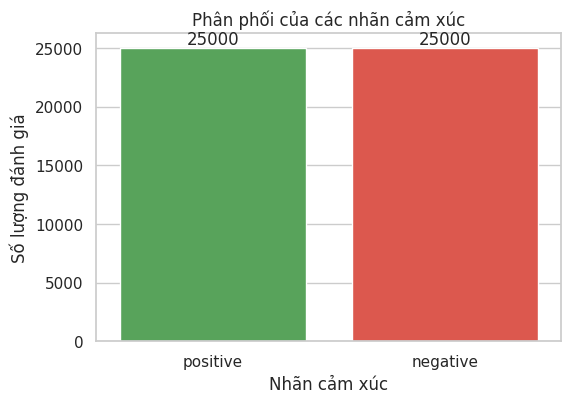

In [5]:
class_counts = df_raw["label"].value_counts().rename_axis("label").reset_index(name="count")
class_counts["ratio"] = class_counts["count"] / class_counts["count"].sum()

display(class_counts)

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=class_counts,
    x="label",
    y="count",
    hue="label",
    palette={
        "positive": "#4CAF50",
        "negative": "#F44336"
    },
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Phân phối của các nhãn cảm xúc")
plt.xlabel("Nhãn cảm xúc")
plt.ylabel("Số lượng đánh giá")
plt.show()

**Nhận xét:**

Hai lớp `positive` và `negative` có số lượng bằng nhau, mỗi lớp chiếm 50% dữ liệu. Điều này cho thấy bộ dữ liệu hoàn toàn cân bằng, giúp giảm rủi ro mô hình bị bias về một lớp cụ thể. Do dữ liệu cân bằng, `accuracy` có thể được sử dụng như một metric chính. Dù vậy, khi huấn luyện, ta vẫn nên đánh giá thêm bằng `Precision`, `Recall` và `F1-score` để có cái nhìn toàn diện hơn.

## 5. Kiểm tra chất lượng dữ liệu

### 5.1 Dữ liệu bị thiếu (Missing values)

In [6]:
missing_summary = df_raw.isna().sum().reset_index()
missing_summary.columns = ["column", "missing_count"]
missing_summary["missing_ratio"] = missing_summary["missing_count"] / len(df_raw)

display(missing_summary)

,column,missing_count,missing_ratio
0,text,0,0.0
1,label,0,0.0
2,label_id,0,0.0


**Nhận xét:**

Không có giá trị bị thiếu ở các cột `text`, `label` và `label_id`. Điều này cho thấy bộ dữ liệu khá sạch, không cần áp dụng các phương pháp xử lý dữ liệu thiếu phức tạp.

### 5.2 Đánh giá rỗng (Empty reviews)

In [7]:
empty_text_count = df_raw["text"].fillna("").astype(str).str.strip().eq("").sum()

print("Số lượng đánh giá rỗng (empty reviews):", empty_text_count)

Số lượng đánh giá rỗng (empty reviews): 0


**Nhận xét:**

Không có các bài đánh giá rỗng trong bộ dữ liệu. Tất cả các dòng đều chứa nội dung văn bản sau khi loại bỏ khoảng trắng ở đầu và cuối chuỗi. Đây là điều kiện lý tưởng để tiếp tục các bước phân tích khám phá (EDA) và tiền xử lý.

### 5.3 Đánh giá trùng lặp (Duplicate reviews)

Các đánh giá trùng lặp có thể gây ra data leakage nếu cùng một nội dung xuất hiện ở cả tập train và tập test. Vì vậy, các dòng trùng lặp ở cột `text` cần được loại bỏ trước khi phân chia tập dữ liệu.

In [8]:
duplicated_rows = df_raw.duplicated().sum()
duplicated_texts = df_raw.duplicated(subset=["text"]).sum()

quality_summary = pd.DataFrame({
    "issue": ["duplicated_rows", "duplicated_texts", "empty_text"],
    "count": [duplicated_rows, duplicated_texts, empty_text_count]
})

display(quality_summary)

if duplicated_texts > 0:
    display(df_raw[df_raw.duplicated(subset=["text"], keep=False)].sort_values("text").head(10))

,issue,count
0,duplicated_rows,418
1,duplicated_texts,418
2,empty_text,0


,text,label,label_id
34058,"""Go Fish"" garnered Rose Troche rightly or wron...",negative,0
47467,"""Go Fish"" garnered Rose Troche rightly or wron...",negative,0
29956,"""Three"" is a seriously dumb shipwreck movie. M...",negative,0
31488,"""Three"" is a seriously dumb shipwreck movie. M...",negative,0
47527,"""Witchery"" might just be the most incoherent a...",negative,0
2976,"""Witchery"" might just be the most incoherent a...",negative,0
7949,'Dead Letter Office' is a low-budget film abou...,negative,0
32260,'Dead Letter Office' is a low-budget film abou...,negative,0
18022,(Spoilers)<br /><br />Oh sure it's based on Mo...,negative,0
22449,(Spoilers)<br /><br />Oh sure it's based on Mo...,negative,0


In [9]:
df = df_raw.copy()

df = df.dropna(subset=["text", "label"])
df = df[df["text"].astype(str).str.strip() != ""]
df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)

df["text"] = df["text"].astype(str)
df["label_id"] = df["label"].map(label2id).astype(int)

print("Kích thước dữ liệu sau bước làm sạch cơ bản:", df.shape)
display(df["label"].value_counts().to_frame("count"))

Kích thước dữ liệu sau bước làm sạch cơ bản: (49582, 3)


,count
label,
positive,24884
negative,24698


## 6. Phân tích Khám phá Dữ liệu (EDA)

### 6.1 Phân tích độ dài văn bản

Phân tích độ dài của các bài đánh giá giúp ta hiểu đặc điểm cơ bản của dữ liệu văn bản trước khi tiến hành tiền xử lý.

Các câu hỏi cần trả lời:

- Độ dài trung bình của một bài đánh giá là bao nhiêu từ?
- Có bài đánh giá nào quá ngắn hoặc quá dài không?
- Phân phối độ dài có bị lệch không?
- Độ dài này ảnh hưởng như thế nào đến việc chọn tham số `max_length` cho Tokenizer của mô hình Transformer ở các bước sau?

In [10]:
df["num_chars"] = df["text"].str.len()
df["num_words"] = df["text"].str.split().str.len()

length_overview = df[["num_chars", "num_words"]].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).T
display(length_overview)

display(df[["text", "label", "num_chars", "num_words"]].head())

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
num_chars,49582.0,1310.568230,990.762238,32.0,699.0,971.0,1592.0,2583.0,3394.0,5181.0,13704.0
num_words,49582.0,231.350167,171.542020,4.0,126.0,173.0,281.0,452.0,591.0,908.0,2470.0


,text,label,num_chars,num_words
0,One of the other reviewers has mentioned that ...,positive,1761,307
1,A wonderful little production. <br /><br />The...,positive,998,162
2,I thought this was a wonderful way to spend ti...,positive,926,166
3,Basically there's a family where a little boy ...,negative,748,138
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317,230


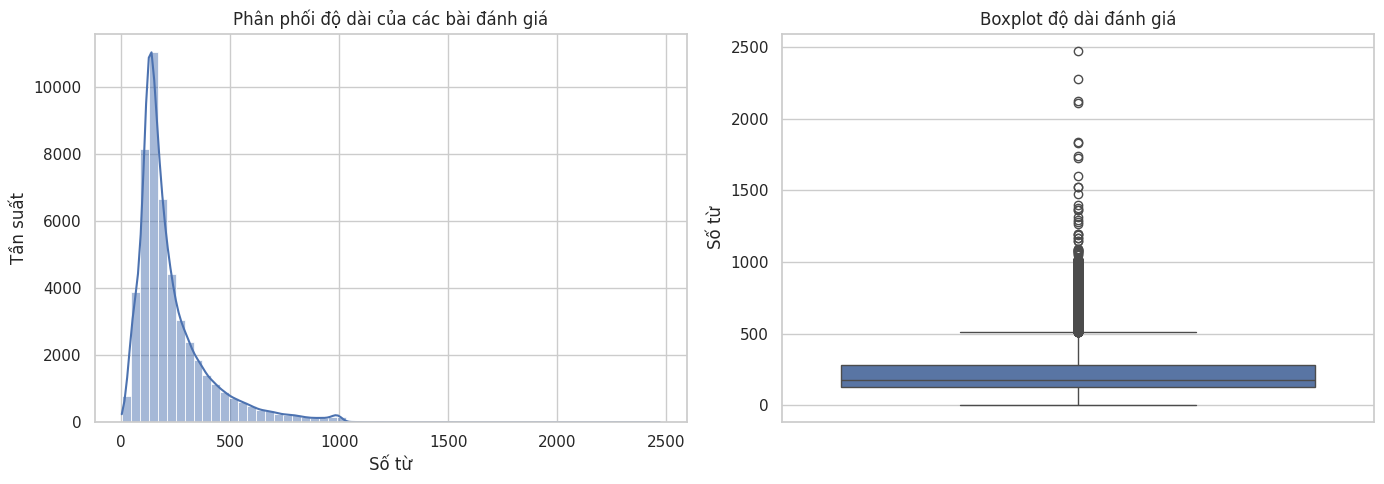

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["num_words"], bins=60, kde=True, ax=axes[0])
axes[0].set_title("Phân phối độ dài của các bài đánh giá")
axes[0].set_xlabel("Số từ")
axes[0].set_ylabel("Tần suất")

sns.boxplot(y=df["num_words"], ax=axes[1])
axes[1].set_title("Boxplot độ dài đánh giá")
axes[1].set_ylabel("Số từ")

plt.tight_layout()
plt.show()

**Nhận xét:**

Độ dài trung bình của các bài đánh giá là khoảng 231 từ, trong khi trung vị là khoảng 173 từ, cho thấy phân phối độ dài bị lệch phải. Phần lớn văn bản có độ dài vừa phải, nhưng vẫn tồn tại những bài rất dài: bài đánh giá dài nhất có 2.470 từ, bách phân vị thứ 95 (95th percentile) ở mức 591 từ và bách phân vị thứ 99 ở mức 908 từ.

Biểu đồ histogram và boxplot cũng xác nhận phần lớn dữ liệu tập trung ở vùng độ dài thấp đến trung bình. Các bài dài tạo thành phần đuôi bên phải của biểu đồ. Không nên xóa các bài quá dài này vì coi chúng là outlier, bởi chúng vẫn chứa nhiều thông tin quan trọng về cảm xúc. Tuy nhiên, cần đặc biệt lưu ý đặc điểm này khi thiết lập `max_length` cho Tokenizer của mô hình Transformer, vì các văn bản vượt quá độ dài tối đa sẽ bị cắt cụt (truncate) ở giai đoạn huấn luyện.

### 6.2 Phân bố độ dài theo nhãn cảm xúc

So sánh độ dài của các bài đánh giá theo từng nhãn cảm xúc (sentiment label) giúp kiểm tra xem các nhận xét tích cực và tiêu cực có xu hướng khác biệt về độ dài hay không.

In [12]:
length_by_label = (
    df.groupby("label")
    .agg(
        count=("num_words", "count"),
        words_mean=("num_words", "mean"),
        words_median=("num_words", "median"),
        words_std=("num_words", "std"),
        words_min=("num_words", "min"),
        words_max=("num_words", "max"),
        chars_mean=("num_chars", "mean"),
        chars_median=("num_chars", "median")
    )
)

display(length_by_label)

,count,words_mean,words_median,words_std,words_min,words_max,chars_mean,chars_median
label,,,,,,,,
negative,24698,229.596607,174.0,165.103430,4,1522,1294.739615,974.0
positive,24884,233.090620,172.0,177.688169,10,2470,1326.278532,969.0


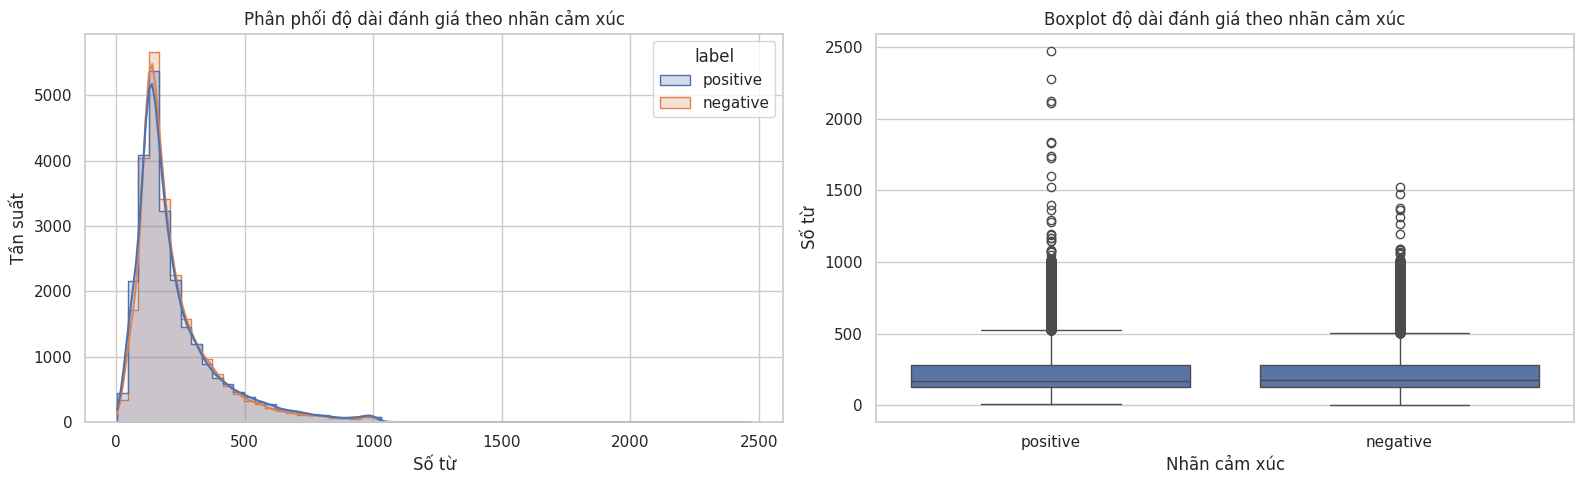

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(
    data=df,
    x="num_words",
    hue="label",
    bins=60,
    kde=True,
    element="step",
    ax=axes[0]
)
axes[0].set_title("Phân phối độ dài đánh giá theo nhãn cảm xúc")
axes[0].set_xlabel("Số từ")
axes[0].set_ylabel("Tần suất")

sns.boxplot(
    data=df,
    x="label",
    y="num_words",
    ax=axes[1]
)
axes[1].set_title("Boxplot độ dài đánh giá theo nhãn cảm xúc")
axes[1].set_xlabel("Nhãn cảm xúc")
axes[1].set_ylabel("Số từ")

plt.tight_layout()
plt.show()

**Nhận xét:**

Độ dài của các bài đánh giá giữa hai nhóm `positive` và `negative` khá tương đồng. Các bài đánh giá `positive` có độ dài trung bình khoảng 233 từ, còn nhóm `negative` là khoảng 230 từ. Trung vị của hai nhóm cũng rất gần nhau, lần lượt ở mức 172 và 174 từ. Điều này cho thấy độ dài văn bản không phải là yếu tố phân biệt mạnh giữa hai nhãn cảm xúc.

Biểu đồ histogram cho thấy phân phối độ dài của hai nhóm gần như chồng lên nhau, phần lớn các bài đánh giá tập trung ở vùng dưới 500 từ và có phần đuôi bên phải kéo dài. Biểu đồ boxplot cũng xác nhận cả hai nhóm đều chứa nhiều bài đánh giá dài bất thường. Vì vậy, sự khác biệt giữa `positive` và `negative` nhiều khả năng nằm ở nội dung, ngữ cảnh và các từ/cụm từ thể hiện cảm xúc, chứ không chỉ đơn thuần nằm ở độ dài của văn bản.

### 6.3 Kiểm định Mann-Whitney U

Do phân phối độ dài văn bản thường lệch phải và không chuẩn, Mann-Whitney U test phù hợp hơn t-test để so sánh hai nhóm độc lập.

- $H_0$: phân phối độ dài của positive và negative giống nhau.
- $H_1$: phân phối độ dài của positive và negative khác nhau.

In [14]:
pos_len = df.loc[df["label"] == "positive", "num_words"]
neg_len = df.loc[df["label"] == "negative", "num_words"]

u_stat, p_value = mannwhitneyu(pos_len, neg_len, alternative="two-sided")

print("Giá trị thống kê Mann-Whitney U:", u_stat)
print("Giá trị p-value:", p_value)

if p_value < 0.05:
    print("Kết luận: Bác bỏ H0. Phân phối độ dài văn bản của hai nhóm có sự khác biệt có ý nghĩa thống kê.")
else:
    print("Kết luận: Không đủ cơ sở bác bỏ H0. Không có sự khác biệt có ý nghĩa thống kê về độ dài giữa hai nhóm.")

Giá trị thống kê Mann-Whitney U: 303932848.5
Giá trị p-value: 0.03500497691950877
Kết luận: Bác bỏ H0. Phân phối độ dài văn bản của hai nhóm có sự khác biệt có ý nghĩa thống kê.


**Nhận xét:**

Kết quả kiểm định Mann-Whitney U cho giá trị `p-value = 0.035`, nhỏ hơn mức ý nghĩa `0.05`, do đó ta bác bỏ giả thuyết `H0`. Điều này cho thấy phân phối độ dài của các bài đánh giá giữa hai nhóm `positive` và `negative` có sự khác biệt mang ý nghĩa thống kê.

Tuy nhiên, cần lưu ý rằng vì bộ dữ liệu có kích thước mẫu lớn, nên ngay cả một chênh lệch thực tế rất nhỏ cũng có thể tạo ra kết quả có ý nghĩa thống kê. Dựa trên các thống kê mô tả và biểu đồ ở phần trước, độ dài trung bình và trung vị của hai nhóm thực chất vẫn khá gần nhau. Vì vậy, độ dài bài đánh giá chủ yếu được dùng để hiểu rõ đặc điểm dữ liệu và hỗ trợ việc lựa chọn tham số `max_length` cho Tokenizer của mô hình Transformer ở giai đoạn sau, chứ không nên được xem là đặc trưng chính để phân loại cảm xúc.

### Hàm hỗ trợ cho EDA văn bản

Phần này tạo tokenizer thủ công phục vụ cho các phân tích thống kê như word distribution, vocabulary overlap, TTR, Zipf Law và bigram analysis.

Khác với cách split thô bằng khoảng trắng, tokenizer này thực hiện một số bước làm sạch nhẹ như lowercase, loại bỏ HTML tags, URLs, ký tự không phải chữ cái và chuẩn hóa khoảng trắng. Mục tiêu là giảm nhiễu khi thống kê từ vựng.

Lưu ý: tokenizer thủ công này chỉ dùng cho EDA. Ở giai đoạn fine-tuning sau này, dữ liệu sẽ được tokenize bằng tokenizer đi kèm với mô hình Transformer được lựa chọn.

In [15]:
def simple_eda_tokenize(text):
    text = str(text).lower()
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-Z']+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.split()

df["eda_tokens"] = df["text"].apply(simple_eda_tokenize)

eda_df = df.copy()

print("Kích thước dữ liệu dùng cho EDA:", eda_df.shape)

Kích thước dữ liệu dùng cho EDA: (49582, 6)


### 6.4 Phân phối từ vựng (Word distribution)

Phần này thống kê các từ xuất hiện với tần suất cao nhất trên toàn bộ tập dữ liệu và chi tiết theo từng nhãn cảm xúc.

,word,count
0,the,661749
1,and,322084
2,a,320689
3,of,287317
4,to,266087
5,is,209613
6,in,185348
7,it,155745
8,i,153680
9,this,149762


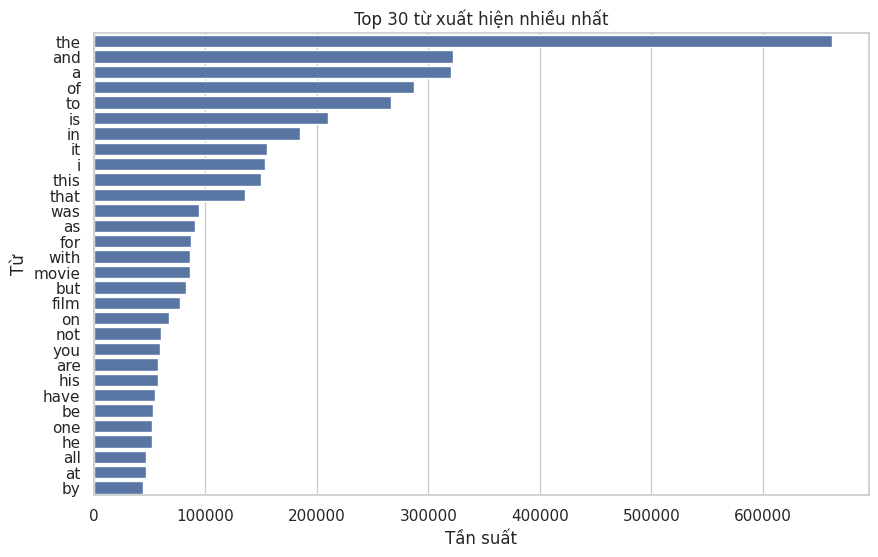

In [16]:
all_counter = Counter(chain.from_iterable(df["eda_tokens"]))

top_words = pd.DataFrame(all_counter.most_common(30), columns=["word", "count"])
display(top_words)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_words, y="word", x="count")
plt.title("Top 30 từ xuất hiện nhiều nhất")
plt.xlabel("Tần suất")
plt.ylabel("Từ")
plt.show()

In [17]:
def get_top_words_by_label(dataframe, label_name, n=30):
    tokens = dataframe.loc[dataframe["label"] == label_name, "eda_tokens"]
    counter = Counter(chain.from_iterable(tokens))
    return pd.DataFrame(counter.most_common(n), columns=["word", "count"])

top_pos = get_top_words_by_label(df, "positive", n=30)
top_neg = get_top_words_by_label(df, "negative", n=30)

print("Top từ phổ biến trong nhóm positive:")
display(top_pos)

print("Top từ phổ biến trong nhóm negative:")
display(top_neg)

Top từ phổ biến trong nhóm positive:


,word,count
0,the,339406
1,and,176016
2,a,163740
3,of,151580
4,to,130869
5,is,111472
6,in,98905
7,it,77869
8,i,72838
9,this,69344


Top từ phổ biến trong nhóm negative:


,word,count
0,the,322343
1,a,156949
2,and,146068
3,of,135737
4,to,135218
5,is,98141
6,in,86443
7,i,80842
8,this,80418
9,it,77876


**Nhận xét:**

Các từ xuất hiện nhiều nhất trong toàn bộ dataset chủ yếu là các stopwords hoặc function words như `the`, `and`, `a`, `of`, `to`, `is`, `in`. Đây là đặc điểm phổ biến của dữ liệu ngôn ngữ tự nhiên, vì các từ này xuất hiện thường xuyên trong hầu hết câu nhưng không trực tiếp thể hiện sentiment.

Một số từ liên quan trực tiếp đến miền dữ liệu phim như `movie`, `film`, `one` cũng xuất hiện với tần suất cao. Điều này cho thấy bộ dữ liệu tập trung đúng vào chủ đề movie reviews.

Khi xét riêng theo từng nhãn, danh sách top words của nhóm `positive` và `negative` khá giống nhau. Cả hai nhóm đều có nhiều từ phổ biến chung như `the`, `and`, `a`, `movie`, `film`, `but`, `not`. Vì vậy, word frequency thô chưa đủ để phân biệt sentiment giữa hai lớp. Cần phân tích thêm các từ mang tính phân biệt lớp, vocabulary overlap, log-ratio words và bigram để hiểu rõ hơn sự khác biệt giữa review tích cực và tiêu cực.

### 6.5 WordCloud

WordCloud giúp quan sát nhanh những từ thường gặp trong từng lớp. Tuy nhiên, WordCloud chỉ là trực quan hóa tần suất, không đủ để kết luận khả năng phân loại.

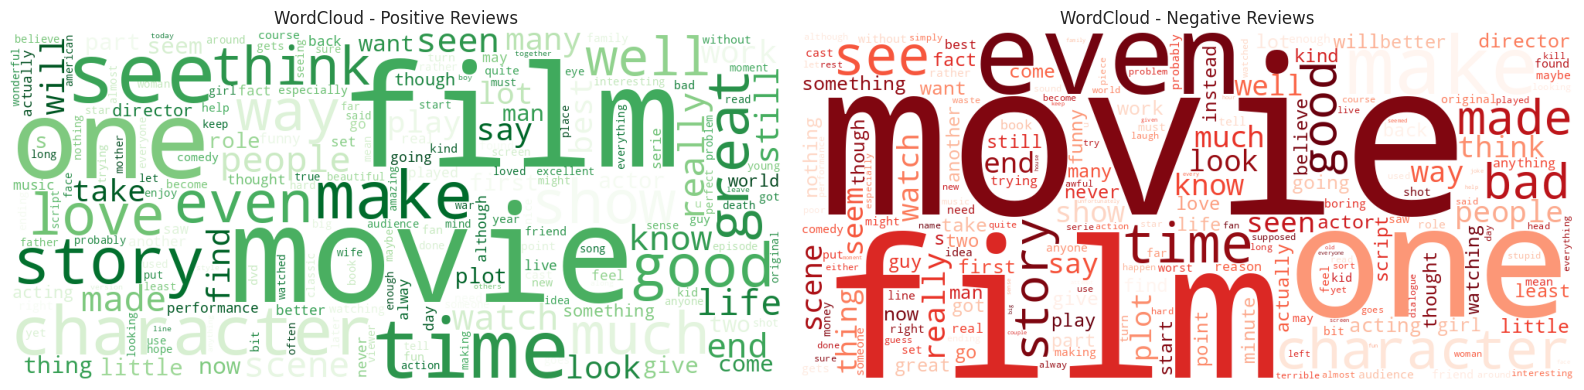

In [18]:
def build_text_from_tokens(token_series):
    return " ".join(chain.from_iterable(token_series))

pos_text = build_text_from_tokens(eda_df.loc[eda_df["label"] == "positive", "eda_tokens"])
neg_text = build_text_from_tokens(eda_df.loc[eda_df["label"] == "negative", "eda_tokens"])

positive_wc = WordCloud(
    width=1000,
    height=450,
    background_color="white",
    max_words=200,
    colormap="Greens"
).generate(pos_text)

negative_wc = WordCloud(
    width=1000,
    height=450,
    background_color="white",
    max_words=200,
    colormap="Reds"
).generate(neg_text)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(positive_wc)
axes[0].axis("off")
axes[0].set_title("WordCloud - Positive Reviews")

axes[1].imshow(negative_wc)
axes[1].axis("off")
axes[1].set_title("WordCloud - Negative Reviews")

plt.tight_layout()
plt.show()

**Nhận xét:**

WordCloud của hai nhóm `positive` và `negative` đều xuất hiện nhiều từ chung như `film`, `movie`, `one`, `character`, `time`, `see`, `make`. Điều này cho thấy hai nhóm review có mức độ chồng lấn từ vựng khá cao vì cùng thuộc miền dữ liệu movie reviews.

Tuy nhiên, WordCloud của nhóm `positive` nổi bật hơn với một số từ mang sắc thái tích cực như `good`, `great`, `love`, `best`, `well`. Trong khi đó, nhóm `negative` xuất hiện nhiều từ có xu hướng tiêu cực hoặc phê bình như `bad`, `nothing`, `least`, `plot`, `script`, `trying`.

Dù vậy, WordCloud chỉ phản ánh tần suất xuất hiện của từ, chưa xét đến ngữ cảnh hoặc quan hệ giữa các từ. Vì vậy, kết quả này chỉ nên dùng để quan sát nhanh đặc điểm dữ liệu, không đủ để kết luận khả năng phân loại sentiment. Các phân tích tiếp theo như vocabulary overlap, log-ratio words và bigram sẽ giúp làm rõ hơn những từ/cụm từ có khả năng phân biệt hai lớp.

### 6.6 Type-Token Ratio

Type-Token Ratio (TTR) đo mức độ đa dạng từ vựng:

$$TTR = \frac{\text{Số token duy nhất}}{\text{Tổng token}}$$

TTR cao hơn nghĩa là văn bản có mức đa dạng từ vựng cao hơn. Tuy nhiên, TTR bị ảnh hưởng bởi độ dài văn bản.

,count,mean,median,std,min,max
label,,,,,,
negative,24698,0.658107,0.658537,0.091153,0.10000,1.0
positive,24884,0.652122,0.651852,0.093463,0.04186,1.0


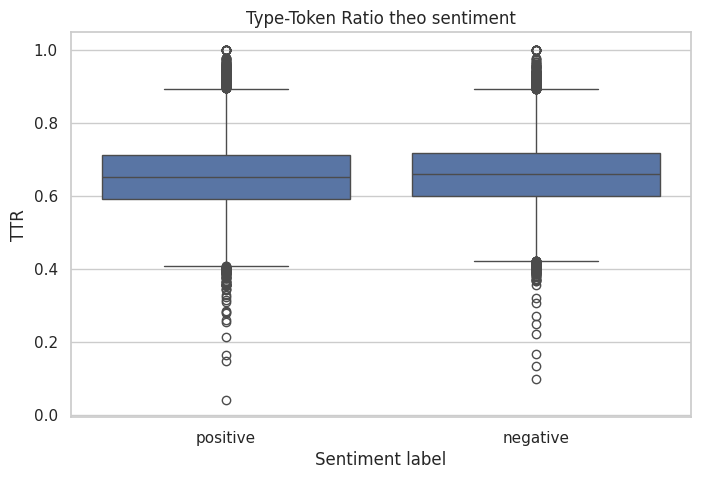

In [19]:
def compute_ttr(tokens):
    if len(tokens) == 0:
        return 0
    return len(set(tokens)) / len(tokens)

df["ttr"] = df["eda_tokens"].apply(compute_ttr)

ttr_summary = df.groupby("label")["ttr"].agg(["count", "mean", "median", "std", "min", "max"])
display(ttr_summary)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="label", y="ttr")
plt.title("Type-Token Ratio theo sentiment")
plt.xlabel("Sentiment label")
plt.ylabel("TTR")
plt.show()

**Nhận xét:**

Type-Token Ratio (TTR) của hai nhóm `positive` và `negative` khá tương đồng. Nhóm `negative` có TTR trung bình khoảng 0.658, còn nhóm `positive` khoảng 0.652. Median của hai nhóm cũng gần nhau, lần lượt khoảng 0.659 và 0.652. Điều này cho thấy mức độ đa dạng từ vựng giữa hai nhóm sentiment không khác biệt quá lớn.

Boxplot cho thấy phân phối TTR của hai nhóm gần như tương tự nhau, dù vẫn tồn tại một số outlier ở cả hai phía. Một số review có TTR rất cao, gần 1.0, thường là các review ngắn với nhiều từ không lặp lại. Ngược lại, một số review có TTR thấp hơn, có thể do văn bản dài hơn hoặc lặp lại nhiều từ.

TTR giúp đánh giá mức độ đa dạng từ vựng, nhưng chỉ số này bị ảnh hưởng mạnh bởi độ dài văn bản. Vì vậy, TTR chỉ nên được dùng như một chỉ báo EDA bổ sung, không phải đặc trưng chính để phân loại sentiment.

### 6.7 Zipf Law

Zipf Law cho biết trong ngôn ngữ tự nhiên, tần suất xuất hiện của từ thường giảm dần theo thứ hạng của từ. Một số ít từ rất phổ biến sẽ xuất hiện với tần suất cao, trong khi phần lớn các từ còn lại xuất hiện với tần suất thấp hơn nhiều.

Về mặt trực giác, Zipf Law có thể được biểu diễn như sau:

$$
f(r) \propto \frac{1}{r}
$$

Trong đó:

- $r$ là thứ hạng của từ trong danh sách tần suất, với $r = 1$ là từ xuất hiện nhiều nhất.
- $f(r)$ là tần suất xuất hiện của từ ở thứ hạng $r$.
- Ký hiệu $\propto$ nghĩa là “tỷ lệ với”.

Trong biểu đồ log-log, nếu đường biểu diễn có xu hướng giảm gần tuyến tính, điều đó cho thấy phân phối từ vựng của bộ dữ liệu có đặc trưng phù hợp với dữ liệu ngôn ngữ tự nhiên.

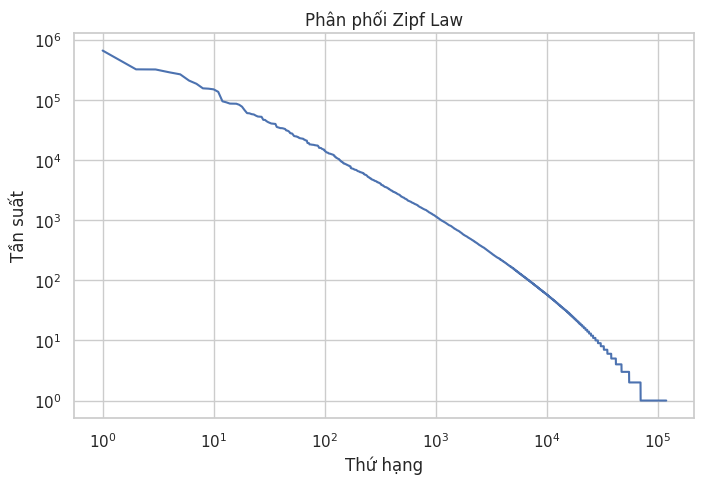

,rank,word,frequency
0,1,the,661749
1,2,and,322084
2,3,a,320689
3,4,of,287317
4,5,to,266087
5,6,is,209613
6,7,in,185348
7,8,it,155745
8,9,i,153680
9,10,this,149762


In [20]:
frequencies = np.array(sorted(all_counter.values(), reverse=True))
ranks = np.arange(1, len(frequencies) + 1)

plt.figure(figsize=(8, 5))
plt.loglog(ranks, frequencies)
plt.title("Phân phối Zipf Law")
plt.xlabel("Thứ hạng")
plt.ylabel("Tần suất")
plt.show()

zipf_preview = pd.DataFrame(
    all_counter.most_common(20),
    columns=["word", "frequency"]
)

zipf_preview.insert(0, "rank", np.arange(1, len(zipf_preview) + 1))

display(zipf_preview)

**Nhận xét:**

Biểu đồ Zipf Law trên thang log-log cho thấy tần suất từ giảm dần theo thứ hạng. Một số ít từ ở thứ hạng cao xuất hiện với tần suất rất lớn, trong khi phần lớn các từ còn lại xuất hiện ít hơn nhiều. Đây là đặc trưng phổ biến của dữ liệu ngôn ngữ tự nhiên.

Đường biểu diễn có xu hướng giảm gần tuyến tính trên thang log-log, cho thấy phân phối từ vựng của IMDb reviews tương đối phù hợp với Zipf Law. Điều này xác nhận rằng dataset có đặc điểm ngôn ngữ tự nhiên hợp lý, với một nhóm nhỏ từ rất phổ biến và một phần đuôi dài gồm nhiều từ hiếm.

Tuy nhiên, các từ có tần suất cao nhất thường là function words hoặc stopwords, không nhất thiết mang nhiều thông tin sentiment. Vì vậy, cần kết hợp thêm các phân tích như vocabulary overlap, log-ratio words và bigram để tìm các từ/cụm từ có khả năng phân biệt cảm xúc tốt hơn.

### 6.8 Vocabulary overlap

Phân tích này giúp kiểm tra mức độ dùng chung từ vựng giữa các bài đánh giá `positive` và `negative`. Với bộ dữ liệu IMDb, mức độ chồng lấn thường khá cao vì cả hai lớp đều bàn luận chung về một chủ đề là phim ảnh.

In [21]:
pos_tokens = df.loc[df["label"] == "positive", "eda_tokens"]
neg_tokens = df.loc[df["label"] == "negative", "eda_tokens"]

pos_vocab = set(chain.from_iterable(pos_tokens))
neg_vocab = set(chain.from_iterable(neg_tokens))

overlap_vocab = pos_vocab & neg_vocab
pos_only_vocab = pos_vocab - neg_vocab
neg_only_vocab = neg_vocab - pos_vocab

jaccard_similarity = len(overlap_vocab) / len(pos_vocab | neg_vocab)

vocab_overlap_df = pd.DataFrame({
    "Metric": [
        "Positive vocabulary size",
        "Negative vocabulary size",
        "Overlap vocabulary size",
        "Positive-only vocabulary size",
        "Negative-only vocabulary size",
        "Jaccard similarity"
    ],
    "Value": [
        len(pos_vocab),
        len(neg_vocab),
        len(overlap_vocab),
        len(pos_only_vocab),
        len(neg_only_vocab),
        jaccard_similarity
    ]
})

display(vocab_overlap_df)

,Metric,Value
0,Positive vocabulary size,87165.000000
1,Negative vocabulary size,82824.000000
2,Overlap vocabulary size,50779.000000
3,Positive-only vocabulary size,36386.000000
4,Negative-only vocabulary size,32045.000000
5,Jaccard similarity,0.425963


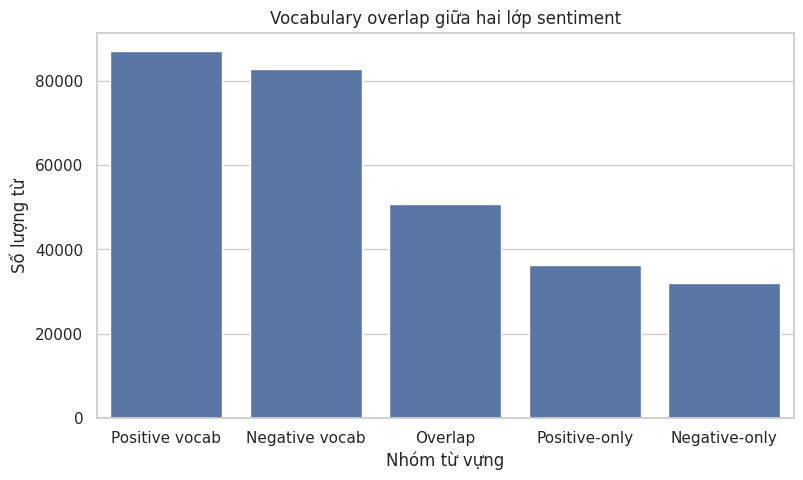

In [22]:
overlap_plot_df = pd.DataFrame({
    "Category": ["Positive vocab", "Negative vocab", "Overlap", "Positive-only", "Negative-only"],
    "Count": [
        len(pos_vocab),
        len(neg_vocab),
        len(overlap_vocab),
        len(pos_only_vocab),
        len(neg_only_vocab)
    ]
})

plt.figure(figsize=(9, 5))
sns.barplot(data=overlap_plot_df, x="Category", y="Count")
plt.title("Vocabulary overlap giữa hai lớp sentiment")
plt.xlabel("Nhóm từ vựng")
plt.ylabel("Số lượng từ")
plt.show()

**Nhận xét:**

Vocabulary size của nhóm `positive` là khoảng 87,165 từ, cao hơn một chút so với nhóm `negative` với khoảng 82,824 từ. Số lượng từ vựng xuất hiện ở cả hai nhóm là 50,779 từ, cho thấy hai lớp có mức độ chồng lấn từ vựng khá lớn. Điều này hợp lý vì cả hai nhóm đều thuộc cùng miền dữ liệu là movie reviews, nên thường sử dụng nhiều từ chung liên quan đến phim, nhân vật, cảnh quay, diễn xuất và cốt truyện.

Tuy nhiên, vẫn có 36,386 từ chỉ xuất hiện trong nhóm `positive` và 32,045 từ chỉ xuất hiện trong nhóm `negative`. Những từ riêng này có thể chứa một phần tín hiệu cảm xúc, nhưng không nên kết luận chỉ dựa trên việc từ có xuất hiện độc quyền ở một lớp hay không, vì nhiều từ hiếm hoặc lỗi chính tả cũng có thể rơi vào nhóm này.

Jaccard similarity đạt khoảng 0.426, cho thấy hai tập từ vựng có mức overlap đáng kể nhưng vẫn tồn tại sự khác biệt. Vì vậy, phân tích vocabulary overlap giúp xác nhận rằng unigram thô chưa đủ để phân loại sentiment. Cần phân tích thêm tần suất tương đối bằng log-ratio words và các cụm từ bằng bigram để tìm các tín hiệu phân biệt cảm xúc rõ hơn.

### 6.9 Phân định từ vựng theo lớp bằng Log-ratio

Việc phân tích chồng lấn từ vựng chỉ cho biết một từ có xuất hiện ở cả hai nhóm hay không. Trong phân tích cảm xúc (sentiment analysis), điều quan trọng hơn là xác định xem từ đó xuất hiện nhiều hơn ở nhóm `positive` hay `negative`.

Do đó, ta sử dụng **Log-ratio** để đo mức độ một từ nghiêng về lớp nào:

$$
\text{log-ratio}(w) = \log \left( \frac{\text{count}_{positive}(w) + 1}{\text{count}_{negative}(w) + 1} \right)
$$

Trong đó:

- $\text{count}_{positive}(w)$ là số lần từ $w$ xuất hiện trong nhóm `positive`.
- $\text{count}_{negative}(w)$ là số lần từ $w$ xuất hiện trong nhóm `negative`.
- Cộng thêm `1` để tránh lỗi chia cho 0 khi một từ chỉ xuất hiện ở một nhóm.

Cách diễn giải:

- **Log-ratio dương:** từ xuất hiện tương đối nhiều hơn trong nhóm `positive`.
- **Log-ratio âm:** từ xuất hiện tương đối nhiều hơn trong nhóm `negative`.
- **Log-ratio gần 0:** từ xuất hiện tương đối cân bằng ở cả hai nhóm.

In [23]:
pos_counter = Counter(chain.from_iterable(pos_tokens))
neg_counter = Counter(chain.from_iterable(neg_tokens))

rows = []
MIN_FREQ = 100

for word in pos_vocab | neg_vocab:
    pos_count = pos_counter.get(word, 0)
    neg_count = neg_counter.get(word, 0)
    total_count = pos_count + neg_count

    if total_count >= MIN_FREQ:
        log_ratio = np.log((pos_count + 1) / (neg_count + 1))
        rows.append({
            "word": word,
            "pos_count": pos_count,
            "neg_count": neg_count,
            "total_count": total_count,
            "log_pos_neg_ratio": log_ratio
        })

word_ratio_df = pd.DataFrame(rows)

top_positive_words = word_ratio_df.sort_values("log_pos_neg_ratio", ascending=False).head(30)
top_negative_words = word_ratio_df.sort_values("log_pos_neg_ratio", ascending=True).head(30)

print("Top từ nghiêng về positive:")
display(top_positive_words)

print("Top từ nghiêng về negative:")
display(top_negative_words)

Top từ nghiêng về positive:


,word,pos_count,neg_count,total_count,log_pos_neg_ratio
2391,ponyo,133,0,133,4.897840
5808,custer,156,7,163,2.976804
2110,edie,112,5,117,2.935628
2438,miyazaki,113,6,119,2.790288
49,felix,159,9,168,2.772589
4228,matthau,229,14,243,2.730029
1204,prot,120,9,129,2.493205
2796,paulie,105,8,113,2.466215
2968,devito,101,8,109,2.427748
6264,haines,96,8,104,2.377486


Top từ nghiêng về negative:


,word,pos_count,neg_count,total_count,log_pos_neg_ratio
1401,uwe,1,150,151,-4.324133
6817,boll,2,182,184,-4.110874
4759,stinker,10,207,217,-2.939643
3925,mst,18,344,362,-2.899105
2750,turd,6,106,112,-2.726919
2725,waste,175,2580,2755,-2.685448
6686,yawn,9,135,144,-2.610070
3463,seagal,26,364,390,-2.604060
1690,unwatchable,15,205,220,-2.555287
4533,incoherent,18,223,241,-2.467207


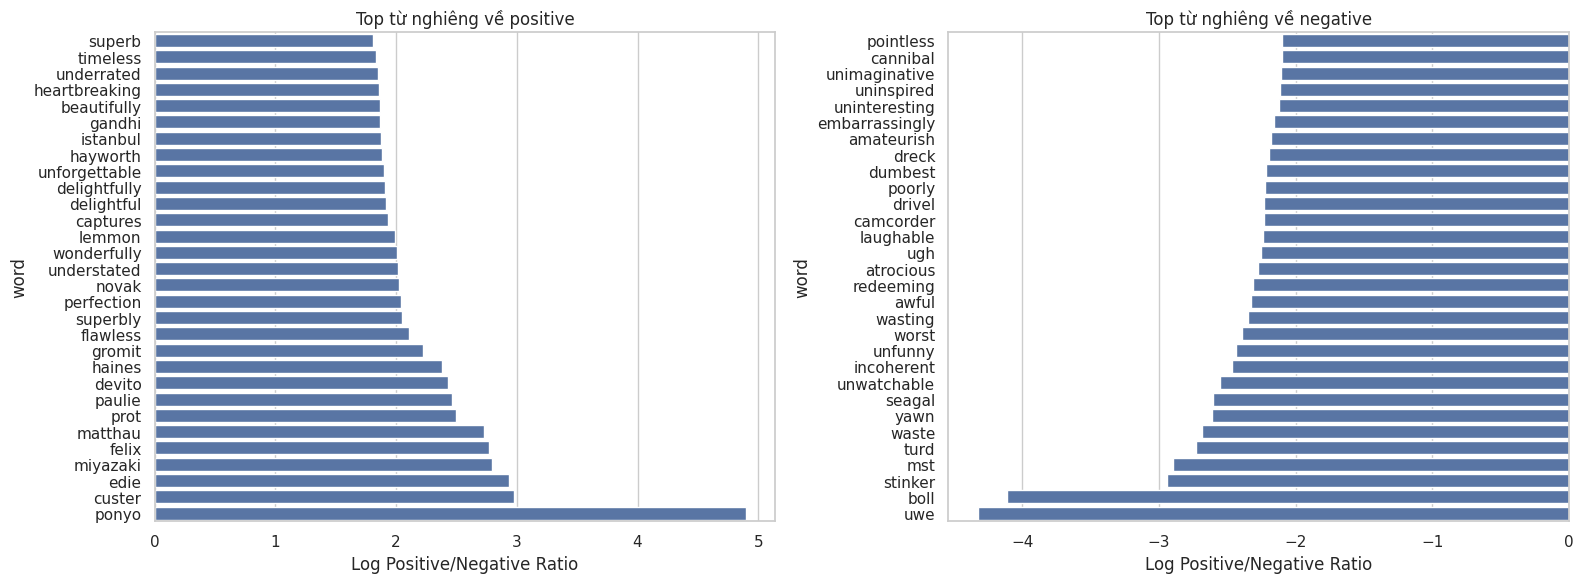

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=top_positive_words.sort_values("log_pos_neg_ratio"),
    y="word",
    x="log_pos_neg_ratio",
    ax=axes[0]
)
axes[0].set_title("Top từ nghiêng về positive")
axes[0].set_xlabel("Log Positive/Negative Ratio")

sns.barplot(
    data=top_negative_words.sort_values("log_pos_neg_ratio", ascending=False),
    y="word",
    x="log_pos_neg_ratio",
    ax=axes[1]
)
axes[1].set_title("Top từ nghiêng về negative")
axes[1].set_xlabel("Log Positive/Negative Ratio")

plt.tight_layout()
plt.show()

**Nhận xét:**

Log-ratio giúp xác định những từ có xu hướng xuất hiện nhiều hơn ở một lớp so với lớp còn lại. Các từ có `log_pos_neg_ratio` dương nghiêng về nhóm `positive`, còn các từ có giá trị âm nghiêng về nhóm `negative`.

Ở nhóm `positive`, nhiều từ mang sắc thái tích cực xuất hiện nổi bật như `flawless`, `superbly`, `perfection`, `wonderfully`, `delightful`, `unforgettable`, `beautifully`, `timeless`, `superb`. Đây là các từ thường được dùng để khen ngợi chất lượng phim, diễn xuất hoặc trải nghiệm xem phim.

Ở nhóm `negative`, nhiều từ thể hiện rõ sắc thái tiêu cực như `waste`, `worst`, `awful`, `unwatchable`, `incoherent`, `unfunny`, `poorly`, `amateurish`, `uninspired`, `pointless`. Những từ này thường xuất hiện trong các review phê bình hoặc đánh giá thấp một bộ phim.

Tuy nhiên, vẫn có một số từ nghiêng mạnh về một lớp nhưng là tên riêng, tên phim, đạo diễn hoặc diễn viên như `ponyo`, `miyazaki`, `uwe`, `boll`, `seagal`. Điều này cho thấy log-ratio không chỉ phản ánh từ mang cảm xúc trực tiếp, mà còn phản ánh các thực thể hoặc chủ đề thường gắn với một nhóm review cụ thể. Vì vậy, phân tích này cần được diễn giải kết hợp với ngữ cảnh và các phân tích khác như bigram.

### 6.10 Bigram analysis

Bigram giúp ta quan sát các cụm gồm hai từ đi liền nhau. Trong sentiment analysis, bigram hữu ích vì ý nghĩa cảm xúc của một từ có thể phụ thuộc vào từ đứng ngay trước hoặc sau nó, ví dụ `not good`, `waste time`, `very good`.

#### 6.10.1 Top bigrams by frequency

Phần này thống kê các bigram có tần suất xuất hiện cao nhất trong từng nhóm `positive` và `negative`.

Mục tiêu là quan sát các cụm hai từ phổ biến nhất trong mỗi nhóm. Tuy nhiên, các bigram có tần suất cao thường là những cụm phổ biến trong tiếng Anh như `of the`, `in the`, `the movie`, nên chưa chắc đã có khả năng phân biệt sentiment tốt.

In [25]:
def build_bigram_counter(token_series):
    counter = Counter()
    for tokens in token_series:
        counter.update([" ".join(bg) for bg in bigrams(tokens)])
    return counter

pos_bigram_counter = build_bigram_counter(df.loc[df["label"] == "positive", "eda_tokens"])
neg_bigram_counter = build_bigram_counter(df.loc[df["label"] == "negative", "eda_tokens"])

top_pos_bigrams = pd.DataFrame(pos_bigram_counter.most_common(30), columns=["bigram", "count"])
top_neg_bigrams = pd.DataFrame(neg_bigram_counter.most_common(30), columns=["bigram", "count"])

print("Top bigram trong nhóm positive:")
display(top_pos_bigrams)

print("Top bigram trong nhóm negative:")
display(top_neg_bigrams)

Top bigram trong nhóm positive:


,bigram,count
0,of the,41480
1,in the,25753
2,is a,15665
3,and the,14333
4,the film,13729
5,this movie,13390
6,to the,12782
7,it is,11504
8,this film,10793
9,this is,10105


Top bigram trong nhóm negative:


,bigram,count
0,of the,35231
1,in the,24242
2,this movie,17694
3,to be,13202
4,the movie,13063
5,and the,12077
6,the film,11400
7,to the,10758
8,this film,10654
9,is a,10282


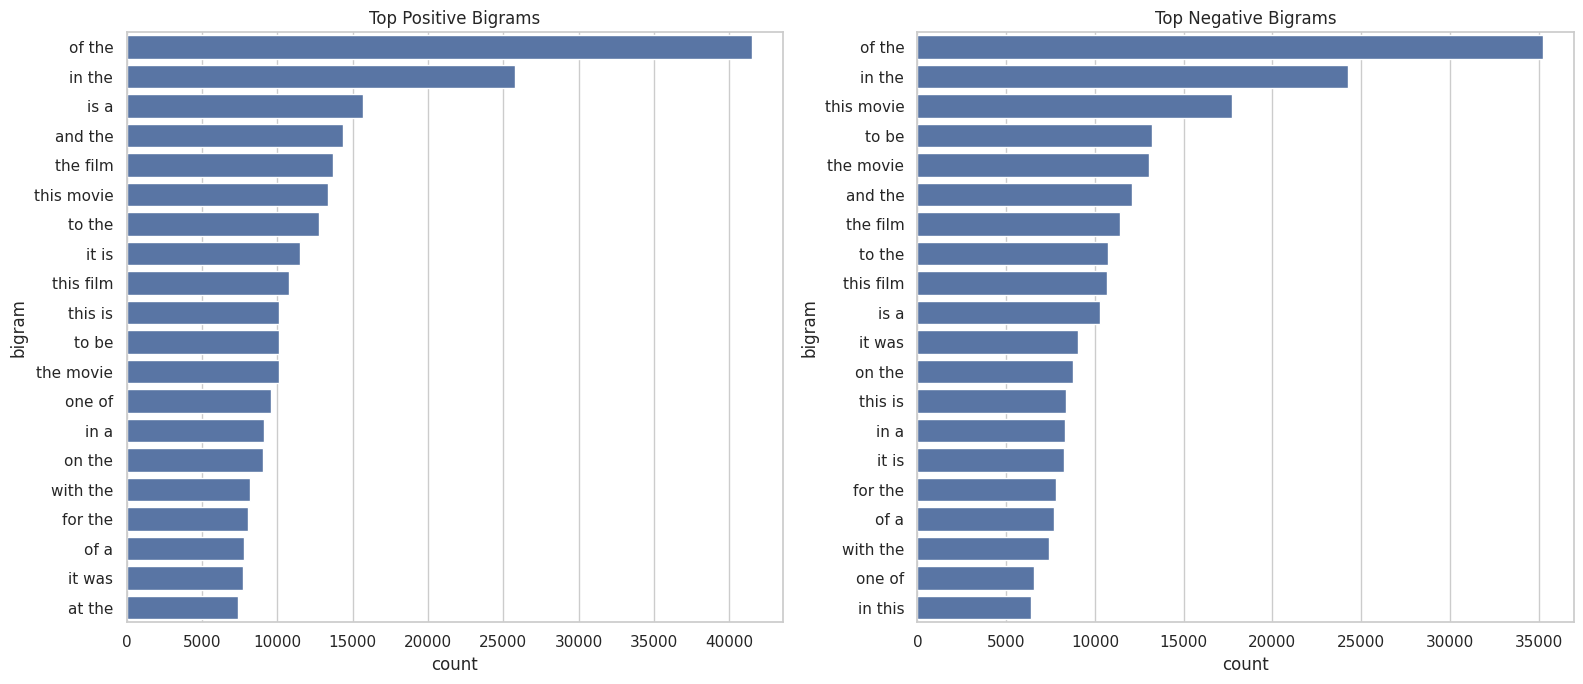

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(data=top_pos_bigrams.head(20), y="bigram", x="count", ax=axes[0])
axes[0].set_title("Top Positive Bigrams")

sns.barplot(data=top_neg_bigrams.head(20), y="bigram", x="count", ax=axes[1])
axes[1].set_title("Top Negative Bigrams")

plt.tight_layout()
plt.show()

**Nhận xét:**

Các bigram xuất hiện nhiều nhất ở cả hai nhóm `positive` và `negative` chủ yếu là các cụm từ phổ biến như `of the`, `in the`, `is a`, `and the`, `to be`, `the movie`, `the film`. Đây là các cụm có tần suất cao nhưng chưa mang nhiều thông tin phân biệt sentiment.

Hai nhóm có nhiều bigram trùng nhau, cho thấy review tích cực và tiêu cực đều sử dụng cấu trúc ngôn ngữ khá giống nhau khi nói về phim. Vì vậy, top bigram theo tần suất thô chủ yếu giúp hiểu đặc điểm ngôn ngữ chung của dataset, nhưng chưa đủ để xác định cụm từ nào nghiêng về sentiment nào.

#### 6.10.2 Sentiment-leaning bigrams using log-ratio

Top bigram theo tần suất thô thường bị chi phối bởi các cụm phổ biến và stopwords. Vì vậy, phần này dùng log-ratio để đo mức độ một bigram nghiêng về nhóm `positive` hay `negative`.

Công thức tương tự như phân tích log-ratio cho unigram:

$$
\log\left(\frac{count_{positive} + 1}{count_{negative} + 1}\right)
$$

- Log-ratio dương: bigram nghiêng về `positive`.
- Log-ratio âm: bigram nghiêng về `negative`.

In [27]:
pos_bigram_counter = build_bigram_counter(df.loc[df["label"] == "positive", "eda_tokens"])
neg_bigram_counter = build_bigram_counter(df.loc[df["label"] == "negative", "eda_tokens"])

all_bigrams = set(pos_bigram_counter.keys()) | set(neg_bigram_counter.keys())

bigram_rows = []
MIN_BIGRAM_FREQ = 50

for bg in all_bigrams:
    pos_count = pos_bigram_counter.get(bg, 0)
    neg_count = neg_bigram_counter.get(bg, 0)
    total_count = pos_count + neg_count

    if total_count >= MIN_BIGRAM_FREQ:
        log_ratio = np.log((pos_count + 1) / (neg_count + 1))
        bigram_rows.append({
            "bigram": bg,
            "pos_count": pos_count,
            "neg_count": neg_count,
            "total_count": total_count,
            "log_pos_neg_ratio": log_ratio
        })

bigram_ratio_df = pd.DataFrame(bigram_rows)

top_positive_bigrams_ratio = bigram_ratio_df.sort_values(
    "log_pos_neg_ratio",
    ascending=False
).head(20)

top_negative_bigrams_ratio = bigram_ratio_df.sort_values(
    "log_pos_neg_ratio",
    ascending=True
).head(20)

print("Top bigram nghiêng về positive:")
display(top_positive_bigrams_ratio)

print("Top bigram nghiêng về negative:")
display(top_negative_bigrams_ratio)

Top bigram nghiêng về positive:


,bigram,pos_count,neg_count,total_count,log_pos_neg_ratio
19022,gunga din,62,0,62,4.143135
9290,red sox,57,0,57,4.060443
11242,rob roy,82,1,83,3.725693
508,was number,65,1,66,3.496508
459,very touching,82,2,84,3.320228
17790,batman returns,54,1,55,3.314186
20004,are amazing,64,2,66,3.075775
13595,also excellent,63,2,65,3.060271
22073,nancy drew,62,2,64,3.044522
15932,beautiful movie,54,2,56,2.908721


Top bigram nghiêng về negative:


,bigram,pos_count,neg_count,total_count,log_pos_neg_ratio
16933,this turkey,0,137,137,-4.927254
12399,this garbage,1,175,176,-4.477337
8563,this stinker,0,79,79,-4.382027
11454,terrible movie,1,151,152,-4.330733
6775,this rubbish,0,73,73,-4.304065
20648,this waste,0,66,66,-4.204693
22195,wasted my,0,65,65,-4.189655
8943,this junk,0,64,64,-4.174387
23511,only redeeming,1,126,127,-4.151040
2654,awful awful,0,62,62,-4.143135


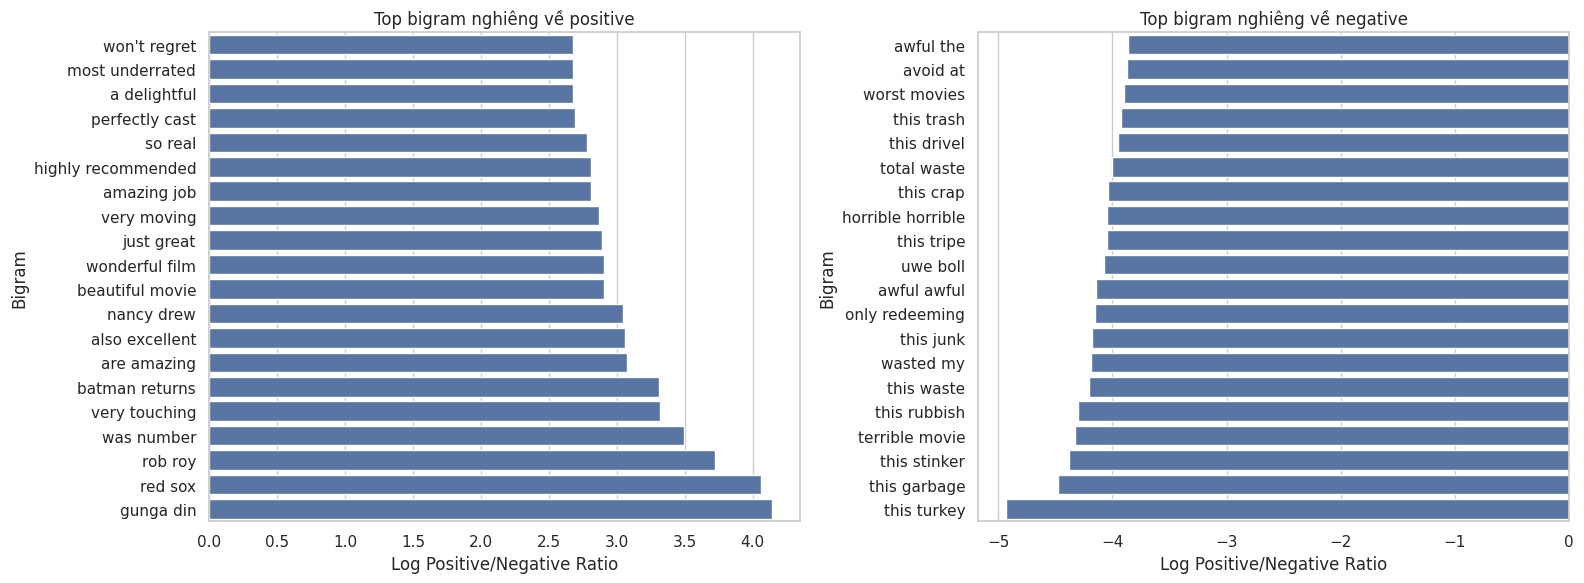

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=top_positive_bigrams_ratio.sort_values("log_pos_neg_ratio"),
    y="bigram",
    x="log_pos_neg_ratio",
    ax=axes[0]
)
axes[0].set_title("Top bigram nghiêng về positive")
axes[0].set_xlabel("Log Positive/Negative Ratio")
axes[0].set_ylabel("Bigram")

sns.barplot(
    data=top_negative_bigrams_ratio.sort_values("log_pos_neg_ratio", ascending=False),
    y="bigram",
    x="log_pos_neg_ratio",
    ax=axes[1]
)
axes[1].set_title("Top bigram nghiêng về negative")
axes[1].set_xlabel("Log Positive/Negative Ratio")
axes[1].set_ylabel("Bigram")

plt.tight_layout()
plt.show()

**Nhận xét:**

Kết quả log-ratio cho bigram cho thấy các cụm hai từ nghiêng về từng nhóm sentiment rõ ràng hơn so với top bigram theo tần suất thô. Ở nhóm `positive`, nhiều bigram mang sắc thái khen ngợi hoặc đánh giá tích cực như `very touching`, `are amazing`, `also excellent`, `beautiful movie`, `wonderful film`, `just great`, `very moving`, `highly recommended`, `perfectly cast`, `a delightful`.

Ở nhóm `negative`, các bigram thể hiện sắc thái phê bình rõ hơn, ví dụ `terrible movie`, `this rubbish`, `this waste`, `wasted my`, `this junk`, `awful awful`, `horrible horrible`, `this crap`, `total waste`, `this drivel`, `this trash`, `worst movies`. Những cụm này cho thấy bigram có khả năng bắt được ngữ cảnh cảm xúc tốt hơn so với unigram riêng lẻ.

Tuy nhiên, vẫn có một số bigram nghiêng mạnh về một lớp nhưng là tên phim, tên nhân vật hoặc thực thể cụ thể như `gunga din`, `red sox`, `rob roy`, `batman returns`, `uwe boll`. Vì vậy, log-ratio bigram là một phân tích hữu ích để tìm tín hiệu sentiment, nhưng vẫn cần diễn giải trong ngữ cảnh của dữ liệu IMDb.

## 7. Text Length Outlier Analysis

Với các bài đánh giá, điểm ngoại lai (outlier) được hiểu là các đoạn văn bản quá ngắn hoặc quá dài.

Chúng ta **không nên** xóa bỏ máy móc các bài đánh giá dài vì chúng vẫn chứa rất nhiều tín hiệu cảm xúc quan trọng. Thay vào đó, mô hình Transformer ở bước sau sẽ xử lý vấn đề này thông qua cơ chế cắt cụt (truncation).

In [29]:
Q1 = df["num_words"].quantile(0.25)
Q3 = df["num_words"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = max(0, Q1 - 1.5 * IQR)
upper_bound = Q3 + 1.5 * IQR

df["is_length_outlier"] = (df["num_words"] < lower_bound) | (df["num_words"] > upper_bound)

outlier_summary = pd.DataFrame({
    "Q1": [Q1],
    "Q3": [Q3],
    "IQR": [IQR],
    "lower_bound": [lower_bound],
    "upper_bound": [upper_bound],
    "num_outliers": [df["is_length_outlier"].sum()],
    "outlier_ratio": [df["is_length_outlier"].mean()]
})

display(outlier_summary)

,Q1,Q3,IQR,lower_bound,upper_bound,num_outliers,outlier_ratio
0,126.0,281.0,155.0,0,513.5,3661,0.073837


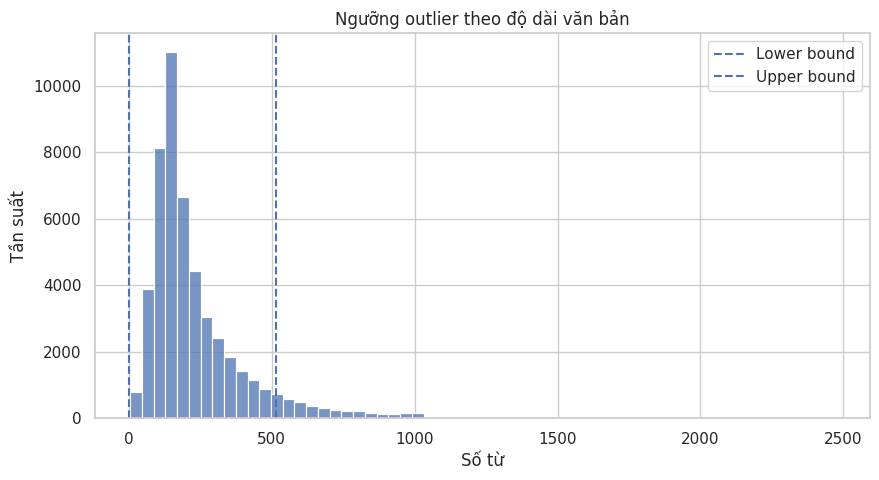

,text,label,num_words
26,"""The Cell"" is an exotic masterpiece, a dizzyin...",positive,570
29,'War movie' is a Hollywood genre that has been...,positive,615
33,One of the most significant quotes from the en...,positive,652
48,Preston Sturgis' THE POWER AND THE GLORY was u...,positive,707
51,"***SPOILERS*** All too, in real life as well a...",positive,621
77,"Maybe it was the title, or the trailer (certai...",negative,608
99,I have been a Mario fan for as long as I can r...,positive,525
101,"Okay, last night, August 18th, 2004, I had the...",negative,766
142,After hearing about George Orwell's prophetic ...,negative,569
156,From the film's first shot - Keira Knightley a...,negative,845


In [30]:
plt.figure(figsize=(10, 5))
sns.histplot(df["num_words"], bins=60)
plt.axvline(lower_bound, linestyle="--", label="Lower bound")
plt.axvline(upper_bound, linestyle="--", label="Upper bound")
plt.title("Ngưỡng outlier theo độ dài văn bản")
plt.xlabel("Số từ")
plt.ylabel("Tần suất")
plt.legend()
plt.show()

display(df.loc[df["is_length_outlier"], ["text", "label", "num_words"]].head(10))

**Nhận xét:**

Theo phương pháp IQR, ngưỡng dưới của độ dài văn bản là `0` từ và ngưỡng trên là khoảng `513.5` từ. Các review có số từ lớn hơn ngưỡng trên được xem là length outlier. Kết quả cho thấy có `3,661` review thuộc nhóm outlier, chiếm khoảng `7.38%` dữ liệu.

Biểu đồ cho thấy phân phối độ dài review bị lệch phải rõ rệt: phần lớn review tập trung ở vùng dưới 500 từ, trong khi một số review dài hơn tạo thành phần đuôi bên phải. Các ví dụ outlier chủ yếu là những review dài, thường chứa nhiều mô tả, phân tích hoặc bình luận chi tiết về bộ phim.

Tuy nhiên, không nên xóa các review dài này chỉ vì chúng là outlier. Trong bài toán sentiment analysis, review dài vẫn có thể chứa nhiều tín hiệu cảm xúc quan trọng. Vì vậy, các outlier về độ dài được giữ lại trong dataset. Ở notebook modeling, vấn đề review quá dài sẽ được xử lý bằng cơ chế `truncation` của tokenizer Transformer thông qua tham số `max_length`.

## 8. Tiền xử lý văn bản và đánh giá tác động

Đối với các mô hình Transformer, không nên preprocessing quá mạnh vì tokenizer và mô hình thường được pre-trained trên văn bản tự nhiên. Vì vậy, pipeline chính trong notebook này chỉ thực hiện làm sạch nhẹ:

1. Văn bản gốc (`text`)
2. Loại bỏ HTML tags
3. Loại bỏ URLs
4. Chuẩn hóa khoảng trắng

Các kỹ thuật preprocessing truyền thống như stopword removal, stemming và lemmatization không được áp dụng cho dữ liệu huấn luyện chính của mô hình Transformer. Nguyên nhân là chúng có thể làm mất ngữ cảnh và các tín hiệu cảm xúc quan trọng như `not`, `never`, `very`, `but`.

Các kỹ thuật này sẽ được phân tích riêng ở Mục 9 để quan sát tác động lên độ dài văn bản, tổng số token và vocabulary size.

### 8.1 Văn bản gốc (`text`)

In [31]:
display(df[["text", "label"]].head(3))

,text,label
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive


### 8.2 Loại bỏ HTML tags

In [32]:
def remove_html(text):
    text = str(text)
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    return text

df["text_no_html"] = df["text"].apply(remove_html)

html_examples = df[df["text"].str.contains(r"<.*?>", regex=True, na=False)]

print("Số review có HTML tags:", len(html_examples))

if len(html_examples) > 0:
    display(html_examples[["text", "text_no_html"]].head(3))
else:
    print("Không tìm thấy HTML tags trong dataset.")
    display(df[["text", "text_no_html"]].head(3))

Số review có HTML tags: 28968


,text,text_no_html
0,One of the other reviewers has mentioned that ...,One of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,A wonderful little production. The filming t...
2,I thought this was a wonderful way to spend ti...,I thought this was a wonderful way to spend ti...


### 8.3 Loại bỏ URLs

In [33]:
def remove_urls(text):
    text = str(text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    return text

df["text_no_url"] = df["text_no_html"].apply(remove_urls)

url_examples = df[df["text_no_html"].str.contains(r"http\S+|www\S+", regex=True, na=False)]

print("Số review có URL:", len(url_examples))

if len(url_examples) > 0:
    display(url_examples[["text_no_html", "text_no_url"]].head(3))
else:
    print("Không tìm thấy URL trong dataset. Bước remove URLs vẫn được giữ trong pipeline để xử lý các dữ liệu nhiễu nếu xuất hiện.")
    display(df[["text_no_html", "text_no_url"]].head(3))

Số review có URL: 231


,text_no_html,text_no_url
742,Mario Lewis of the Competitive Enterprise Inst...,Mario Lewis of the Competitive Enterprise Inst...
907,Following directly from where the story left o...,Following directly from where the story left o...
971,"Possible Spoilers, Perhaps. I must say that ""C...","Possible Spoilers, Perhaps. I must say that ""C..."


### 8.4 Chuẩn hóa khoảng trắng

In [34]:
def normalize_whitespace(text):
    text = str(text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def clean_text_for_transformer(text):
    text = remove_html(text)
    text = remove_urls(text)
    text = normalize_whitespace(text)
    return text

df["clean_text"] = df["text"].apply(clean_text_for_transformer)

display(df[["text", "text_no_html", "text_no_url", "clean_text", "label", "label_id"]].head(3))

,text,text_no_html,text_no_url,clean_text,label,label_id
0,One of the other reviewers has mentioned that ...,One of the other reviewers has mentioned that ...,One of the other reviewers has mentioned that ...,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,A wonderful little production. The filming t...,A wonderful little production. The filming t...,A wonderful little production. The filming tec...,positive,1
2,I thought this was a wonderful way to spend ti...,I thought this was a wonderful way to spend ti...,I thought this was a wonderful way to spend ti...,I thought this was a wonderful way to spend ti...,positive,1


**Nhận xét:**

Cột `clean_text` là kết quả cuối cùng sau các bước remove HTML tags, remove URLs và normalize whitespace. Đây là phiên bản văn bản được dùng cho bước chia train/validation/test và notebook modeling tiếp theo. Pipeline này chỉ làm sạch nhẹ, không loại bỏ stopwords, không stemming và không lemmatization để giữ lại ngữ cảnh tự nhiên của review.

### 8.5 Phân tích tác động của các bước tiền xử lý
Phần này đo lường sự thay đổi về độ dài, tổng số token và kích thước tập từ vựng sau mỗi bước tiền xử lý. Mục tiêu là đảm bảo quá trình làm sạch giúp loại bỏ nhiễu nhưng không làm hỏng nội dung cốt lõi của văn bản.

In [35]:
def token_list_for_metrics(series):
    return series.fillna("").astype(str).str.lower().str.split()

def get_text_metrics(series):
    token_series = token_list_for_metrics(series)
    all_tokens = list(chain.from_iterable(token_series))
    lengths = token_series.apply(len)

    return {
        "avg_words": lengths.mean(),
        "median_words": lengths.median(),
        "max_words": lengths.max(),
        "total_tokens": len(all_tokens),
        "vocab_size": len(set(all_tokens)),
    }

impact_df = pd.DataFrame({
    "raw_text": get_text_metrics(df["text"]),
    "remove_html": get_text_metrics(df["text_no_html"]),
    "remove_url": get_text_metrics(df["text_no_url"]),
    "normalize_whitespace": get_text_metrics(df["clean_text"]),
}).T

display(impact_df)

,avg_words,median_words,max_words,total_tokens,vocab_size
raw_text,231.350167,173.0,2470.0,11470804.0,390931.0
remove_html,229.059054,172.0,2459.0,11357206.0,365408.0
remove_url,229.055383,172.0,2459.0,11357024.0,365219.0
normalize_whitespace,229.055383,172.0,2459.0,11357024.0,365219.0


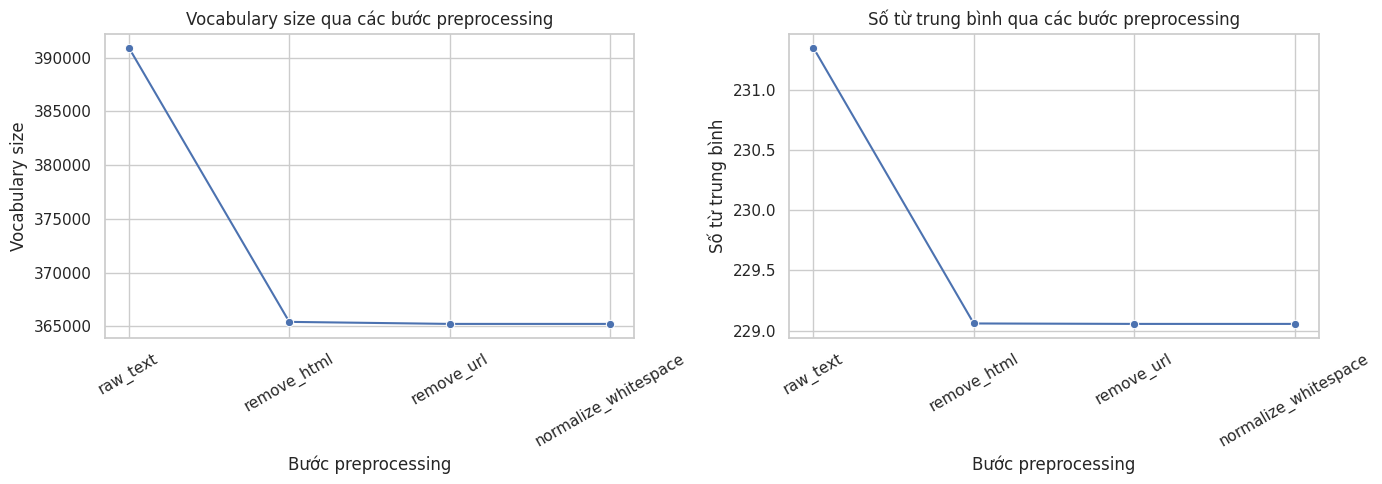

In [36]:
impact_plot_df = impact_df.reset_index().rename(columns={"index": "step"})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=impact_plot_df, x="step", y="vocab_size", marker="o", ax=axes[0])
axes[0].set_title("Vocabulary size qua các bước preprocessing")
axes[0].set_xlabel("Bước preprocessing")
axes[0].set_ylabel("Vocabulary size")
axes[0].tick_params(axis="x", rotation=30)

sns.lineplot(data=impact_plot_df, x="step", y="avg_words", marker="o", ax=axes[1])
axes[1].set_title("Số từ trung bình qua các bước preprocessing")
axes[1].set_xlabel("Bước preprocessing")
axes[1].set_ylabel("Số từ trung bình")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

**Nhận xét:**

Các bước preprocessing nhẹ làm giảm một phần độ dài và vocabulary size của dữ liệu. Sau khi loại bỏ HTML tags, số từ trung bình giảm từ khoảng `231.35` xuống `229.06`, tổng số token giảm từ khoảng `11.47M` xuống `11.36M`, và vocabulary size giảm từ khoảng `390,931` xuống `365,408`. Điều này cho thấy HTML tags như `<br /><br />` tạo ra nhiễu đáng kể trong thống kê từ vựng.

Bước remove URLs tiếp tục làm giảm nhẹ vocabulary size từ `365,408` xuống `365,219`, nhưng tác động nhỏ hơn nhiều so với remove HTML. Điều này phù hợp với kết quả trước đó vì số review chứa URL không quá lớn so với toàn bộ dataset.

Sau bước normalize whitespace, các chỉ số gần như không thay đổi so với bước remove URLs. Điều này cho thấy bước chuẩn hóa khoảng trắng chủ yếu giúp văn bản gọn và nhất quán hơn, nhưng không làm thay đổi đáng kể số lượng từ hoặc vocabulary size.

Nhìn chung, pipeline preprocessing chính đã đạt mục tiêu làm sạch nhẹ: giảm nhiễu từ HTML/URL nhưng không làm biến đổi mạnh nội dung văn bản. Vì vậy, `clean_text` phù hợp để dùng làm dữ liệu đầu vào cho notebook modeling với Transformer.

## 9. Phân tích tác động của preprocessing truyền thống

Phần này phân tích tác động của một số kỹ thuật preprocessing truyền thống như lowercase, loại bỏ ký tự đặc biệt, loại bỏ số, stopword removal, stemming và lemmatization.

Các kỹ thuật này có thể hữu ích với các phương pháp NLP truyền thống như Bag-of-Words hoặc TF-IDF, vì chúng giúp giảm nhiễu và giảm kích thước từ vựng. Tuy nhiên, chúng không được sử dụng cho pipeline Transformer chính vì có thể làm mất ngữ cảnh, thay đổi cấu trúc tự nhiên của câu và làm mất các tín hiệu cảm xúc quan trọng.

Trong notebook này, các phiên bản văn bản sau preprocessing truyền thống chỉ được dùng để so sánh sự thay đổi về độ dài văn bản, tổng số token và vocabulary size. 

In [ ]:
# Tạo dataframe riêng cho phần phân tích preprocessing truyền thống
ablation_df = df.copy()

### 9.1 Lowercase, special characters và numbers

Phần này phân tích tác động của một số bước chuẩn hóa phổ biến trong NLP truyền thống:

- `lowercase_text`: chuyển toàn bộ văn bản về chữ thường.
- `no_special_chars_text`: loại bỏ phần lớn ký tự đặc biệt, chỉ giữ lại chữ cái và khoảng trắng.
- `no_numbers_text`: loại bỏ chữ số.

Các bước này có thể giúp giảm vocabulary size trong mô hình truyền thống. Tuy nhiên, với Transformer, nhiều tokenizer đã tự xử lý lowercase hoặc subword tokenization, nên không nhất thiết cần áp dụng thủ công cho pipeline chính.

In [38]:
def lowercase_text(text):
    return str(text).lower()

def remove_special_chars_text(text):
    text = str(text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def remove_numbers_text(text):
    text = str(text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

ablation_df["lowercase_text"] = ablation_df["clean_text"].apply(lowercase_text)
ablation_df["no_special_chars_text"] = ablation_df["lowercase_text"].apply(remove_special_chars_text)
ablation_df["no_numbers_text"] = ablation_df["no_special_chars_text"].apply(remove_numbers_text)

In [39]:
def version_metrics(series):
    token_series = series.fillna("").astype(str).str.lower().str.split()
    all_tokens = list(chain.from_iterable(token_series))
    lengths = token_series.apply(len)

    return {
        "avg_words": lengths.mean(),
        "median_words": lengths.median(),
        "max_words": lengths.max(),
        "total_tokens": len(all_tokens),
        "vocab_size": len(set(all_tokens))
    }

In [40]:
basic_preprocessing_impact = pd.DataFrame({
    "clean_text": version_metrics(ablation_df["clean_text"]),
    "lowercase_text": version_metrics(ablation_df["lowercase_text"]),
    "no_special_chars_text": version_metrics(ablation_df["no_special_chars_text"]),
    "no_numbers_text": version_metrics(ablation_df["no_numbers_text"]),
}).T

display(basic_preprocessing_impact)

,avg_words,median_words,max_words,total_tokens,vocab_size
clean_text,229.055383,172.0,2459.0,11357024.0,365219.0
lowercase_text,229.055383,172.0,2459.0,11357024.0,365219.0
no_special_chars_text,234.364386,176.0,2494.0,11620255.0,99278.0
no_numbers_text,234.364386,176.0,2494.0,11620255.0,99278.0


**Nhận xét:**

Việc chuyển sang lowercase gần như không làm thay đổi các chỉ số so với `clean_text`. Điều này xảy ra vì hàm `version_metrics` đã chuyển token về chữ thường khi tính vocabulary size, nên `clean_text` và `lowercase_text` cho kết quả giống nhau ở bảng thống kê này.

Sau khi loại bỏ ký tự đặc biệt, vocabulary size giảm mạnh từ `365,219` xuống `99,278`. Điều này cho thấy nhiều token trong dữ liệu gốc chứa dấu câu, ký tự đặc biệt, hoặc các biến thể khác nhau của cùng một từ. Tuy nhiên, số từ trung bình và tổng số token lại tăng nhẹ, vì một số ký tự đặc biệt bị thay bằng khoảng trắng, khiến một vài chuỗi bị tách thành nhiều token hơn.

Bước loại bỏ số gần như không tạo thêm thay đổi so với `no_special_chars_text`, cho thấy phần lớn chữ số đã bị loại bỏ hoặc tách ra trong bước remove special characters trước đó.

Nhìn chung, các bước này giúp giảm vocabulary size đáng kể trong các phương pháp NLP truyền thống. Tuy nhiên, chúng không được dùng cho pipeline Transformer chính vì có thể làm thay đổi hình thức tự nhiên của văn bản và làm mất một số tín hiệu ngữ cảnh.

### 9.2 Stopword removal impact

Stopword removal là kỹ thuật loại bỏ các từ phổ biến như `the`, `a`, `is`, `and`. Trong các mô hình truyền thống, bước này có thể giúp giảm nhiễu và giảm số chiều của không gian đặc trưng.

Tuy nhiên, trong sentiment analysis, một số từ thường bị xem là stopwords như `not`, `no`, `never`, `very`, `but` lại có thể đóng vai trò quan trọng trong việc biểu diễn cảm xúc hoặc đảo nghĩa câu. Vì vậy, phần này chỉ dùng để phân tích tác động, không dùng cho pipeline Transformer chính.

In [41]:
english_stopwords = set(stopwords.words("english"))

def remove_stopwords_text(text):
    tokens = str(text).split()
    return " ".join([tok for tok in tokens if tok.lower() not in english_stopwords])

ablation_df["no_stopwords_text"] = ablation_df["clean_text"].apply(remove_stopwords_text)

stopword_impact = pd.DataFrame({
    "clean_text": version_metrics(ablation_df["clean_text"]),
    "no_stopwords_text": version_metrics(ablation_df["no_stopwords_text"]),
}).T

display(stopword_impact)

,avg_words,median_words,max_words,total_tokens,vocab_size
clean_text,229.055383,172.0,2459.0,11357024.0,365219.0
no_stopwords_text,123.331693,92.0,1457.0,6115032.0,365035.0


**Nhận xét:**

Sau khi loại bỏ stopwords, số từ trung bình giảm mạnh từ khoảng `229.06` xuống `123.33` từ, median giảm từ `172` xuống `92` từ và tổng số token giảm từ khoảng `11.36M` xuống `6.12M`. Điều này cho thấy stopwords chiếm tỷ lệ rất lớn trong IMDb reviews, đúng với đặc điểm của dữ liệu ngôn ngữ tự nhiên.

Tuy nhiên, vocabulary size gần như không thay đổi nhiều, chỉ giảm nhẹ từ `365,219` xuống `365,035`. Nguyên nhân là stopword removal chủ yếu loại bỏ các từ rất phổ biến lặp lại nhiều lần, nhưng số lượng loại từ stopwords là không lớn so với toàn bộ vocabulary.

Với các mô hình truyền thống như Bag-of-Words hoặc TF-IDF, việc loại bỏ stopwords có thể giúp giảm tổng số token và giảm nhiễu. Tuy nhiên, trong sentiment analysis, một số stopwords như `not`, `never`, `very`, `but` có thể mang thông tin cảm xúc quan trọng. Vì vậy, phiên bản `no_stopwords_text` chỉ được dùng để phân tích tác động, không dùng cho pipeline Transformer chính.

### 9.3 Stemming vs Lemmatization impact

Stemming và lemmatization là hai kỹ thuật giúp giảm vocabulary sparsity bằng cách đưa các biến thể của từ về dạng ngắn hơn hoặc dạng gốc.

- `stemming`: cắt hậu tố theo quy tắc, thường làm giảm vocabulary mạnh hơn nhưng có thể tạo ra token không còn là từ tự nhiên.
- `lemmatization`: đưa từ về dạng gốc hợp lệ hơn về mặt ngôn ngữ, thường giữ ý nghĩa tốt hơn stemming nhưng giảm vocabulary ít hơn.

Phần này chỉ dùng để phân tích tác động của preprocessing truyền thống, không áp dụng cho dữ liệu đầu vào của mô hình Transformer cuối cùng.

In [42]:
porter = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def stem_text(text):
    tokens = str(text).split()
    return " ".join([porter.stem(tok) for tok in tokens])

def lemmatize_text(text):
    tokens = str(text).split()
    return " ".join([lemmatizer.lemmatize(tok) for tok in tokens])

ablation_df["stemmed_text"] = ablation_df["clean_text"].apply(stem_text)
ablation_df["lemmatized_text"] = ablation_df["clean_text"].apply(lemmatize_text)

morph_impact = pd.DataFrame({
    "clean_text": version_metrics(ablation_df["clean_text"]),
    "stemmed_text": version_metrics(ablation_df["stemmed_text"]),
    "lemmatized_text": version_metrics(ablation_df["lemmatized_text"]),
}).T

display(morph_impact)

,avg_words,median_words,max_words,total_tokens,vocab_size
clean_text,229.055383,172.0,2459.0,11357024.0,365219.0
stemmed_text,229.055383,172.0,2459.0,11357024.0,333912.0
lemmatized_text,229.055383,172.0,2459.0,11357024.0,359793.0


**Nhận xét:**

Stemming và lemmatization không làm thay đổi số từ trung bình, median, max words hay tổng số token, vì hai kỹ thuật này chỉ biến đổi hình thức của từng token chứ không thêm hoặc xóa token khỏi văn bản.

Tuy nhiên, vocabulary size có sự thay đổi rõ rệt. Sau stemming, vocabulary size giảm từ `365,219` xuống `333,912`, cho thấy nhiều biến thể của cùng một từ đã được gom về dạng rút gọn. Lemmatization cũng làm giảm vocabulary size nhưng nhẹ hơn, từ `365,219` xuống `359,793`, vì lemmatization thường đưa từ về dạng gốc hợp lệ hơn thay vì cắt mạnh như stemming.

Điều này cho thấy stemming có tác động mạnh hơn trong việc giảm vocabulary sparsity, nhưng cũng dễ làm biến dạng từ và mất sắc thái ý nghĩa. Lemmatization giữ dạng từ tự nhiên hơn, nhưng mức giảm vocabulary ít hơn. Với pipeline Transformer chính, cả hai kỹ thuật này không được sử dụng vì mô hình cần giữ ngữ cảnh và hình thức văn bản gần với dữ liệu tự nhiên.

### 9.4 Tổng hợp tác động của các phiên bản preprocessing

Phần này tổng hợp tất cả các phiên bản văn bản đã tạo ở trên để so sánh tác động tổng thể của từng kỹ thuật preprocessing truyền thống.

In [43]:
traditional_preprocessing_impact = pd.DataFrame({
    "clean_text": version_metrics(ablation_df["clean_text"]),
    "lowercase_text": version_metrics(ablation_df["lowercase_text"]),
    "no_special_chars_text": version_metrics(ablation_df["no_special_chars_text"]),
    "no_numbers_text": version_metrics(ablation_df["no_numbers_text"]),
    "no_stopwords_text": version_metrics(ablation_df["no_stopwords_text"]),
    "stemmed_text": version_metrics(ablation_df["stemmed_text"]),
    "lemmatized_text": version_metrics(ablation_df["lemmatized_text"]),
}).T

display(traditional_preprocessing_impact)

,avg_words,median_words,max_words,total_tokens,vocab_size
clean_text,229.055383,172.0,2459.0,11357024.0,365219.0
lowercase_text,229.055383,172.0,2459.0,11357024.0,365219.0
no_special_chars_text,234.364386,176.0,2494.0,11620255.0,99278.0
no_numbers_text,234.364386,176.0,2494.0,11620255.0,99278.0
no_stopwords_text,123.331693,92.0,1457.0,6115032.0,365035.0
stemmed_text,229.055383,172.0,2459.0,11357024.0,333912.0
lemmatized_text,229.055383,172.0,2459.0,11357024.0,359793.0


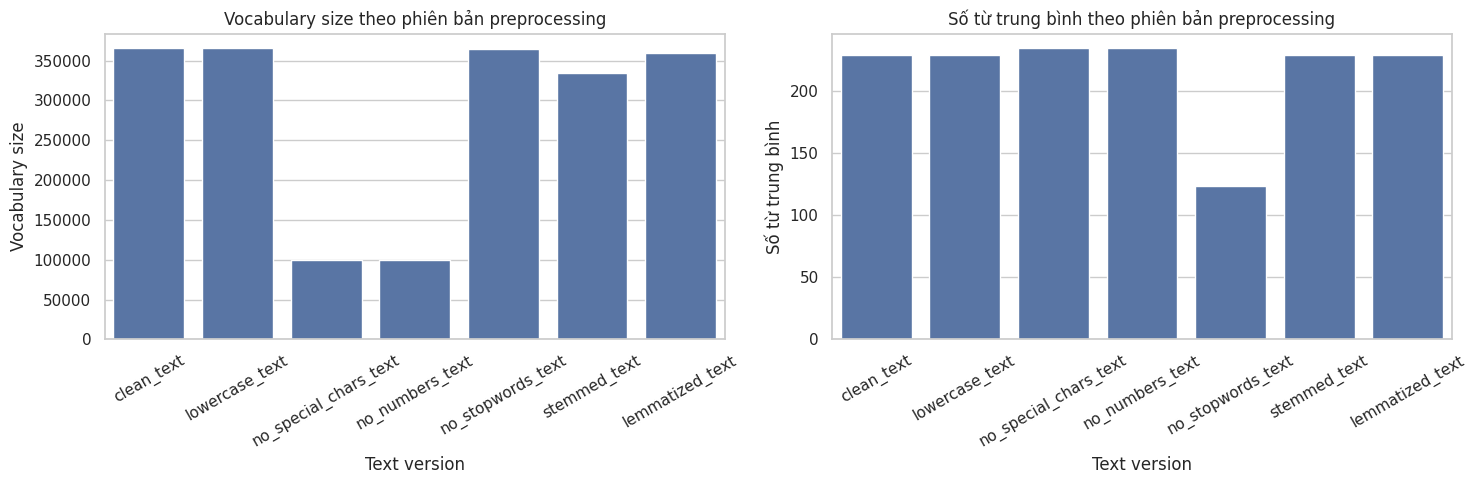

In [44]:
traditional_plot_df = traditional_preprocessing_impact.reset_index().rename(
    columns={"index": "text_version"}
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(
    data=traditional_plot_df,
    x="text_version",
    y="vocab_size",
    ax=axes[0]
)
axes[0].set_title("Vocabulary size theo phiên bản preprocessing")
axes[0].set_xlabel("Text version")
axes[0].set_ylabel("Vocabulary size")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(
    data=traditional_plot_df,
    x="text_version",
    y="avg_words",
    ax=axes[1]
)
axes[1].set_title("Số từ trung bình theo phiên bản preprocessing")
axes[1].set_xlabel("Text version")
axes[1].set_ylabel("Số từ trung bình")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [45]:
example_cols = [
    "clean_text",
    "lowercase_text",
    "no_special_chars_text",
    "no_numbers_text",
    "no_stopwords_text",
    "stemmed_text",
    "lemmatized_text",
    "label"
]

display(ablation_df[example_cols].head(3))

,clean_text,lowercase_text,no_special_chars_text,no_numbers_text,no_stopwords_text,stemmed_text,lemmatized_text,label
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...,One reviewers mentioned watching 1 Oz episode ...,one of the other review ha mention that after ...,One of the other reviewer ha mentioned that af...,positive
1,A wonderful little production. The filming tec...,a wonderful little production. the filming tec...,a wonderful little production the filming tech...,a wonderful little production the filming tech...,wonderful little production. filming technique...,a wonder littl production. the film techniqu i...,A wonderful little production. The filming tec...,positive
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...,i thought thi wa a wonder way to spend time on...,I thought this wa a wonderful way to spend tim...,positive


**Nhận xét tổng hợp:**

Các kỹ thuật preprocessing truyền thống tạo ra tác động khác nhau lên độ dài văn bản và vocabulary size. `lowercase_text` gần như không thay đổi so với `clean_text` trong bảng thống kê, vì quá trình tính metric đã quy đổi token về chữ thường. Trong khi đó, `no_special_chars_text` và `no_numbers_text` làm vocabulary size giảm rất mạnh, từ khoảng `365,219` xuống `99,278`, do nhiều token chứa dấu câu, ký tự đặc biệt hoặc biến thể hình thức được chuẩn hóa lại.

`no_stopwords_text` làm giảm mạnh số từ trung bình, từ khoảng `229.06` xuống `123.33`, và tổng số token giảm từ khoảng `11.36M` xuống `6.12M`. Tuy nhiên, vocabulary size gần như không giảm nhiều, vì stopwords là nhóm từ có số lượng loại từ không lớn nhưng xuất hiện lặp lại với tần suất rất cao.

`stemmed_text` và `lemmatized_text` không làm thay đổi số lượng token, nhưng làm giảm vocabulary size. Stemming giảm vocabulary mạnh hơn lemmatization, từ `365,219` xuống `333,912`, trong khi lemmatization giảm nhẹ hơn xuống `359,793`. Điều này cho thấy stemming gom nhiều biến thể từ hơn, nhưng cũng dễ làm biến dạng từ hơn.

Các ví dụ trước/sau preprocessing cho thấy những kỹ thuật truyền thống có thể làm văn bản ngắn hơn hoặc thay đổi hình thức token đáng kể. Vì vậy, các phiên bản này chỉ dùng để phân tích tác động của preprocessing, không dùng cho pipeline Transformer chính. Dữ liệu đầu vào cuối cùng cho notebook modeling vẫn là `clean_text`, tức là văn bản chỉ được làm sạch nhẹ bằng cách remove HTML tags, remove URLs và normalize whitespace.

## 10. Train / Validation / Test Split

Tạo split chính thức cho notebook fine-tuning tiếp theo.

Tỷ lệ đề xuất:

- Train: 80%
- Validation: 10%
- Test: 10%

Dùng stratified split để giữ tỷ lệ nhãn cân bằng giữa các tập.

In [46]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df["label_id"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=SEED,
    stratify=temp_df["label_id"]
)

print("Kích thước tập train:", train_df.shape)
print("Kích thước tập validation:", val_df.shape)
print("Kích thước tập test:", test_df.shape)

split_distribution = pd.DataFrame({
    "train (%)": train_df["label"].value_counts(normalize=True) * 100,
    "validation (%)": val_df["label"].value_counts(normalize=True) * 100,
    "test (%)": test_df["label"].value_counts(normalize=True) * 100,
})

display(split_distribution.round(2))

Kích thước tập train: (39665, 11)
Kích thước tập validation: (4958, 11)
Kích thước tập test: (4959, 11)


,train (%),validation (%),test (%)
label,,,
positive,50.19,50.18,50.19
negative,49.81,49.82,49.81


In [47]:
train_model_df = train_df[["clean_text", "label", "label_id"]].reset_index(drop=True)
val_model_df = val_df[["clean_text", "label", "label_id"]].reset_index(drop=True)
test_model_df = test_df[["clean_text", "label", "label_id"]].reset_index(drop=True)

display(train_model_df.head())

,clean_text,label,label_id
0,I am one of Jehovah's Witnesses and I also wor...,positive,1
1,Amongst the standard one liner type action fil...,positive,1
2,Realty television crew are assigned to cover a...,negative,0
3,The funniest scene of this movie is probably w...,negative,0
4,There have been far too few mainstream films s...,positive,1


## 11. Phân tích độ dài token với tokenizer Transformer tham khảo

Các mô hình Transformer thường có giới hạn độ dài đầu vào. Vì vậy, phần này sử dụng một tokenizer Transformer tham khảo để ước lượng số lượng token của mỗi review.

Mục tiêu là hỗ trợ lựa chọn giá trị `max_length` phù hợp cho notebook fine-tuning tiếp theo.

### 11.1 Phân phối độ dài token

In [48]:
# Tokenizer này chỉ dùng để phân tích sơ bộ độ dài token.
# Mô hình Transformer cuối cùng sẽ được lựa chọn ở notebook modeling.
TOKENIZER_CHECKPOINT = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_CHECKPOINT)

print("Tokenizer tham khảo:", TOKENIZER_CHECKPOINT)
print("Tokenizer này chỉ dùng để phân tích độ dài token, chưa phải mô hình cuối cùng.")

Tokenizer tham khảo: bert-base-uncased
Tokenizer này chỉ dùng để phân tích độ dài token, chưa phải mô hình cuối cùng.


In [49]:
token_lengths = []

texts = df["clean_text"].tolist()

for start in range(0, len(texts), TOKENIZER_BATCH_SIZE):
    batch_texts = texts[start:start + TOKENIZER_BATCH_SIZE]
    encoded = tokenizer(
        batch_texts,
        truncation=False,
        padding=False,
        add_special_tokens=True
    )
    token_lengths.extend([len(input_ids) for input_ids in encoded["input_ids"]])

df["transformer_token_len"] = token_lengths

token_len_summary = df["transformer_token_len"].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
)

display(token_len_summary.to_frame("transformer_token_len"))

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (531 > 512). Running this sequence through the model will result in indexing errors


,transformer_token_len
count,49582.000000
mean,294.325804
std,218.329698
min,10.000000
50%,220.000000
75%,357.000000
90%,574.000000
95%,754.000000
99%,1143.000000
max,3047.000000


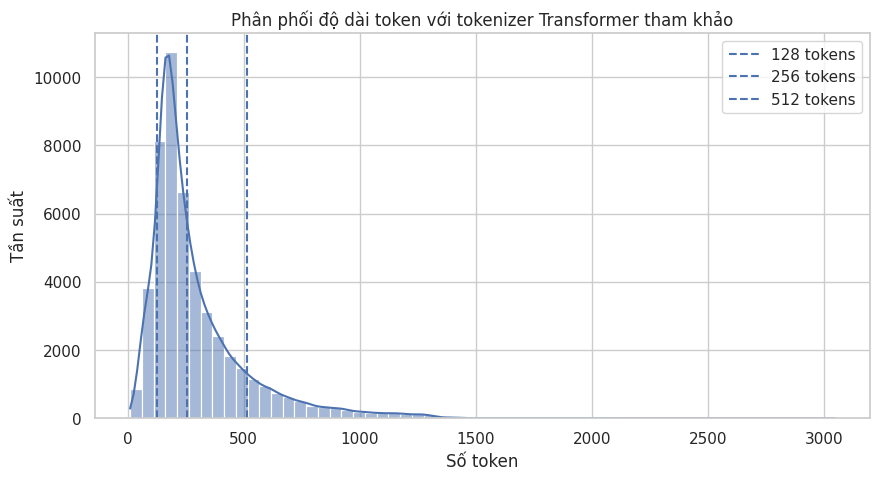

In [50]:
plt.figure(figsize=(10, 5))
sns.histplot(df["transformer_token_len"], bins=60, kde=True)
plt.axvline(128, linestyle="--", label="128 tokens")
plt.axvline(256, linestyle="--", label="256 tokens")
plt.axvline(512, linestyle="--", label="512 tokens")
plt.title("Phân phối độ dài token với tokenizer Transformer tham khảo")
plt.xlabel("Số token")
plt.ylabel("Tần suất")
plt.legend()
plt.show()

In [51]:
length_thresholds = [128, 256, 512]
coverage_rows = []

for threshold in length_thresholds:
    coverage_rows.append({
        "max_length": threshold,
        "num_reviews_within_limit": int((df["transformer_token_len"] <= threshold).sum()),
        "coverage_ratio": float((df["transformer_token_len"] <= threshold).mean()),
        "truncated_ratio": float((df["transformer_token_len"] > threshold).mean()),
    })

coverage_df = pd.DataFrame(coverage_rows)
display(coverage_df)

,max_length,num_reviews_within_limit,coverage_ratio,truncated_ratio
0,128,6116,0.123351,0.876649
1,256,29424,0.593441,0.406559
2,512,43218,0.871647,0.128353


**Nhận xét:**

Phân phối độ dài token bị lệch phải rõ rệt. Trung bình mỗi review có khoảng `294` token, median là `220` token, trong khi percentile 95 đạt khoảng `754` token và giá trị lớn nhất lên tới `3,047` token. Điều này cho thấy nhiều review dài hơn giới hạn đầu vào phổ biến của các mô hình Transformer.

Với `max_length = 128`, chỉ khoảng `12.34%` review nằm trong giới hạn, nghĩa là phần lớn dữ liệu sẽ bị truncate. Với `max_length = 256`, tỷ lệ review nằm trong giới hạn tăng lên khoảng `59.34%`, nhưng vẫn có khoảng `40.66%` review bị truncate. Với `max_length = 512`, khoảng `87.16%` review được giữ trong giới hạn, chỉ còn khoảng `12.84%` bị truncate.

Do đó, `max_length = 256` là lựa chọn cân bằng nếu ưu tiên tốc độ và giới hạn tài nguyên của Colab. Tuy nhiên, nếu GPU/RAM cho phép, `max_length = 512` sẽ giữ được nhiều thông tin hơn cho IMDb reviews.

### 11.2 Lựa chọn tham số `max_length`

Trade-off trong thực tế:

- `MAX_LENGTH = 128`: nhẹ nhất, train nhanh hơn, nhưng truncate quá nhiều review.
- `MAX_LENGTH = 256`: cân bằng giữa tốc độ và lượng thông tin giữ lại, phù hợp nếu tài nguyên GPU hạn chế.
- `MAX_LENGTH = 512`: giữ được nhiều thông tin hơn, nhưng tốn GPU/RAM và thời gian train hơn.

Trong notebook này, `MAX_LENGTH = 256` được chọn làm cấu hình khởi đầu an toàn cho Colab. Giá trị này có thể được điều chỉnh lại trong notebook modeling tùy theo mô hình Transformer được chọn và tài nguyên tính toán thực tế.

In [52]:
MAX_LENGTH = 256

print("MAX_LENGTH được chọn:", MAX_LENGTH)

selected_coverage = coverage_df.loc[coverage_df["max_length"] == MAX_LENGTH]
display(selected_coverage)

MAX_LENGTH được chọn: 256


,max_length,num_reviews_within_limit,coverage_ratio,truncated_ratio
1,256,29424,0.593441,0.406559


## 12. Lưu kết quả

In [53]:
train_path = os.path.join(OUTPUT_DIR, "train.csv")
val_path = os.path.join(OUTPUT_DIR, "validation.csv")
test_path = os.path.join(OUTPUT_DIR, "test.csv")

train_model_df.to_csv(train_path, index=False)
val_model_df.to_csv(val_path, index=False)
test_model_df.to_csv(test_path, index=False)

print("Đã lưu các file processed dataset vào thư mục:", OUTPUT_DIR)
print("Train file:", train_path)
print("Validation file:", val_path)
print("Test file:", test_path)

Đã lưu các file processed dataset vào thư mục: ../data/processed
Train file: ../data/processed/train.csv
Validation file: ../data/processed/validation.csv
Test file: ../data/processed/test.csv


## Tổng kết

1. **Chất lượng dữ liệu:** Bộ dữ liệu IMDb ban đầu có 50.000 mẫu và hai nhãn `positive`/`negative` cân bằng. Sau khi kiểm tra chất lượng dữ liệu, không phát hiện missing values hoặc empty reviews; các duplicate reviews đã được loại bỏ trước khi chia dữ liệu.

2. **Đặc trưng ngôn ngữ (EDA):** Các review có phân phối độ dài lệch phải, trong đó phần lớn review có độ dài vừa phải nhưng vẫn tồn tại nhiều review rất dài. Độ dài giữa hai nhóm `positive` và `negative` khá tương đồng, nên độ dài văn bản không phải là yếu tố phân biệt sentiment mạnh. Các phân tích WordCloud, TTR, Zipf Law, vocabulary overlap, log-ratio words và bigram cho thấy dữ liệu có đặc trưng ngôn ngữ tự nhiên rõ ràng và ngữ cảnh đóng vai trò quan trọng trong phân loại cảm xúc.

3. **Chiến lược preprocessing chính:** Pipeline chính cho Transformer chỉ thực hiện làm sạch nhẹ gồm remove HTML tags, remove URLs và normalize whitespace. Cách xử lý này giúp giảm nhiễu nhưng vẫn giữ cấu trúc tự nhiên và các tín hiệu cảm xúc quan trọng trong câu.

4. **Phân tích preprocessing truyền thống:** Các kỹ thuật lowercase, remove special characters/numbers, stopword removal, stemming và lemmatization đã được phân tích để quan sát tác động lên độ dài văn bản, tổng số token và vocabulary size. Các phiên bản này chỉ dùng để phân tích, không dùng cho pipeline Transformer chính.

5. **Chuẩn bị cho modeling:** Dữ liệu đã được chia thành train/validation/test theo stratified split và lưu thành file CSV. Phân tích độ dài token bằng tokenizer Transformer tham khảo giúp ước lượng `MAX_LENGTH`, trong đó `MAX_LENGTH = 256` được chọn làm cấu hình khởi đầu cho notebook fine-tuning tiếp theo.